<h1 style="text-align:center;">Song Success Prediction Model</h1>
<h2 style="text-align:center;">Data Wrangling & EDA</h2>

<h4 style="text-align:center;">by Cameron Hicks</h3>

In [333]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import time
from urllib.parse import quote
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# Data Wrangling

## Spotify Data

### Import Data

Spotify Analytics Dataset imported into a DataFrame titled "raw_data".

Data Source: https://www.kaggle.com/datasets/rohiteng/spotify-music-analytics-dataset-20152025?resource=download

In [2]:
raw_data = pd.read_csv('../../Data/spotify_2015_2025_85k.csv')

### Inspect Spotify Data

Before making any changes to the data it needs to be inspected. In the cells below I fully inspect the data to become familiar with it.

In [3]:
raw_data.shape

(85000, 19)

We can see that there are 85k records and 19 features in the raw data frame

In [4]:
raw_data.dtypes

track_id             object
track_name           object
artist_name          object
album_name           object
release_date         object
genre                object
duration_ms           int64
popularity            int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
instrumentalness    float64
tempo               float64
stream_count          int64
country              object
explicit              int64
label                object
dtype: object

In [5]:
# Print the first 5 rows of the data to see what the DataFrame and records look like
raw_data.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent


Column insights from the head of the DataFrame

- <strong>Track ID</strong> records show unique id numbers that would not be easily identified without a key. There is not a visable system to determining the track id at first glance.
- <strong>Track Name, Artist Name,</strong> and <strong>Album Name</strong> are strings with the relavent data
- <strong>Release date</strong> contains the year, month, and day of the release in one column. It should be converted to a datetime object.
- <strong>Duration</strong> is measured in milliseconds. This will likely prove useful for computer analysis, but it may be helpful to add a column that shows the duration in minutes:seconds:milliseconds. 
- <strong>Popularity</strong> is measured by a two digit number for each example in the head. This column is our primary target feature for the model and will need to be inspected further.
- <strong>Danceability</strong> and <strong>Energy</strong> are measured as a float between 0 and 1
- <strong>Energy</strong> is float values between 0-1 showing the energy of the song
- <strong>Key</strong> is a numeric value incidating the key of the song
- <strong>Loudness</strong> is consistently a negative float representing the loudness of the track in decibels.
- <strong>Mode</strong> is a boolean column representing if the songs key is major or minor (0 = minor 1 = major)
- <strong>Instrumentalness</strong> is a float value between 0-1
- <strong>Tempo</strong> is Beats Per Minute
- <strong>Stream count</strong> is the number of streams for the track. We can assume that number of streams has a direct correlation with popularity of a song, and becuase our target model is to predict popularity prior to or at the early relase stages, this column will likely be dropped or become a target feature for the model to predict.
- <strong>Country</strong> represents what Country the song performed well. In Data Exploration it will need to be explored further to determine if songs that performed well in multiple countries have multiple recoreds, or if this column actually shows the top performing country for the song.
- <strong>Explicit</strong> - boolean showing if the song is marked as explicit
- <strong>Label</strong> is the label that released the song

### Edits and Additions to Spotify Data

In [6]:
# Ensure the release date is a datetime object
raw_data['release_date'] = pd.to_datetime(raw_data['release_date'])

In [7]:
raw_data.dtypes

track_id                    object
track_name                  object
artist_name                 object
album_name                  object
release_date        datetime64[ns]
genre                       object
duration_ms                  int64
popularity                   int64
danceability               float64
energy                     float64
key                          int64
loudness                   float64
mode                         int64
instrumentalness           float64
tempo                      float64
stream_count                 int64
country                     object
explicit                     int64
label                       object
dtype: object

In [8]:
# Add a second duration column for EDA.
raw_data['duration_mm:ss:ms'] = pd.to_timedelta(raw_data['duration_ms'], unit='ms').dt.components.apply(
    lambda x: f"{x.minutes:02d}:{x.seconds:02d}:{x.milliseconds:02d}", axis=1)

In [9]:
raw_data.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,duration_mm:ss:ms
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,03:54:194
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records,06:15:706
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,04:49:191
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music,03:29:484
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent,02:07:435


Next we will see how many unique values each column contains

In [10]:
# How many unique values does each column have?

for col in raw_data.columns:
    print(f"{col}: {raw_data[col].nunique()}")

track_id: 85000
track_name: 68951
artist_name: 62391
album_name: 43170
release_date: 4018
genre: 12
duration_ms: 75084
popularity: 99
danceability: 95
energy: 98
key: 12
loudness: 5401
mode: 2
instrumentalness: 801
tempo: 13967
stream_count: 2250
country: 10
explicit: 2
label: 8
duration_mm:ss:ms: 75084


Notice while there are 85,000 unique track id's there are only 68,951 unique track names. This could mean that there are songs that share the same name, or it could mean that some songs have duplicate records. Most likely it is a combination of both. This means we will need to be careful and thorough when inspecting and dropping duplicates.

### Missing and Null Values - Spotify Data

In this next section we will handle missing and null values.

In [11]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   track_id           85000 non-null  object        
 1   track_name         84979 non-null  object        
 2   artist_name        85000 non-null  object        
 3   album_name         84954 non-null  object        
 4   release_date       85000 non-null  datetime64[ns]
 5   genre              85000 non-null  object        
 6   duration_ms        85000 non-null  int64         
 7   popularity         85000 non-null  int64         
 8   danceability       85000 non-null  float64       
 9   energy             85000 non-null  float64       
 10  key                85000 non-null  int64         
 11  loudness           85000 non-null  float64       
 12  mode               85000 non-null  int64         
 13  instrumentalness   85000 non-null  float64       
 14  tempo 

Inspecting the info for the raw dataframe, we can see that there are some columns that do not have 85000 non-null values. 

In [12]:
raw_data.isnull().sum()

track_id              0
track_name           21
artist_name           0
album_name           46
release_date          0
genre                 0
duration_ms           0
popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
instrumentalness      0
tempo                 0
stream_count          0
country               0
explicit              0
label                 0
duration_mm:ss:ms     0
dtype: int64

Track name contains 21 missing values.

In [13]:
raw_data[raw_data['track_name'].isna()].sort_values(by='artist_name')

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,duration_mm:ss:ms
71667,TRK-25F6BEF5437F,NaN,Aaron Nixon,Sense,2018-03-11,Jazz,142662,54,0.24,0.99,10,-22.01,0,0.784,106.37,18000,Germany,0,Independent,02:22:662
47946,TRK-04F201CCB2A2,NaN,Abigail Thomas,Quality police,2024-09-02,Country,281128,65,0.50,0.74,2,-17.92,1,0.352,89.28,79000,Brazil,0,XL Recordings,04:41:128
13675,TRK-530AF3473134,NaN,Brenda Calderon,Offer despite,2019-02-27,Indie,159043,35,0.51,0.58,9,-48.51,0,0.415,67.81,1000,India,1,Sony Music,02:39:43
83574,TRK-A7D9098C8152,NaN,Daniel Cox,Director perhaps,2024-09-08,Indie,153590,59,0.73,0.60,2,-40.17,1,0.498,86.30,1000,Germany,0,Independent,02:33:590
49470,TRK-A14E1F1D05D9,NaN,Eric Flores,Option there,2023-07-06,Jazz,360475,31,0.67,0.47,10,-34.79,1,0.420,102.42,1000,Mexico,0,Sony Music,06:00:475
67131,TRK-EBA6A845A873,NaN,Erin Petersen,Page,2017-01-18,Folk,322652,31,0.83,0.23,10,-28.57,0,0.447,88.73,1000,Canada,0,Sony Music,05:22:652
80537,TRK-EA13F1E7FB64,NaN,Frank Wolfe,Reflect,2021-12-02,EDM,196142,52,0.85,0.89,8,-37.18,1,0.053,83.38,1000,United Kingdom,1,Warner Music,03:16:142
71882,TRK-FEABDC31C767,NaN,Gary Tanner,Throughout,2019-10-08,Hip-Hop,398762,65,0.65,0.20,3,-40.41,1,0.643,64.43,3000,United Kingdom,0,Columbia,06:38:762
21451,TRK-224386735616,NaN,Jesse Carpenter,Right,2021-06-11,Country,269462,50,0.32,0.72,8,-26.73,0,0.604,115.88,1000,United Kingdom,0,Warner Music,04:29:462
61767,TRK-6D055555336C,NaN,Jonathan Sloan,Get involve,2018-03-06,Metal,403909,53,0.44,0.42,7,-13.95,1,0.450,146.22,3000,Japan,0,XL Recordings,06:43:909


With 21 tracks that do not have values for track name, it is best to fill these values with the string "Unknown" to keep their data to train and test the model. It is possible that the clients utalize the final version of the model will have working titles or no track name for the new songs, and therefore may use the 'Unknown' or null value when using the model.

Before filling the missing values, are there any existing songs with the string 'Unknown' already?

In [18]:
unknown_tracks = raw_data[raw_data['track_name'].str.lower() == 'unknown']

print(f"There are {len(unknown_tracks)} tracks with the name Unknown")

There are 0 tracks with the name Unknown


With 0 existing track names as "Unknown", missing track names will be filled with the string "Unknwon"

In [19]:
raw_data['track_name'] = raw_data['track_name'].fillna('Unknown')

In [20]:
unknown_tracks_new = raw_data[raw_data['track_name'].str.lower() == 'unknown']

print(f"There are {len(unknown_tracks_new)} tracks with the name Unknown")

There are 21 tracks with the name Unknown


Album name contains 46 missing values

In [21]:
raw_data[raw_data['album_name'].isna()].sort_values(by='artist_name')

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,duration_mm:ss:ms
21674,TRK-65DC223A2CFC,Popular west,Abigail Hall,NaN,2023-01-04,R&B,389171,48,0.34,0.94,0,-50.14,0,0.314,93.10,7000,France,0,Columbia,06:29:171
59848,TRK-48D99EDCE521,Fish will population,Amanda Harding,NaN,2024-01-19,Classical,307684,40,0.33,0.28,9,-34.30,0,0.658,176.70,1000,Germany,0,Columbia,05:07:684
65401,TRK-3C0B06599311,Suffer when and,Amanda Smith,NaN,2024-10-05,R&B,194777,78,0.23,0.66,0,-51.36,0,0.647,120.59,1298000,United States,1,Sony Music,03:14:777
13690,TRK-827D10EBAB35,News,Anna Villarreal,NaN,2023-08-08,Rock,149590,35,0.09,0.61,6,-47.29,1,0.128,128.09,1000,France,0,Universal Music,02:29:590
31598,TRK-073E69DAAF9D,Its part,Anne Burns,NaN,2015-06-13,Pop,133232,47,0.53,0.42,7,-47.02,1,0.677,133.69,1000,United Kingdom,1,Independent,02:13:232
59011,TRK-39F249470C99,Throw Democrat,Anthony Anderson,NaN,2017-04-04,Rock,328667,49,0.59,0.93,5,-45.25,0,0.228,170.44,1000,United Kingdom,1,Island Records,05:28:667
29079,TRK-54D6D4C1826C,Leader yeah,Anthony Daniels,NaN,2021-07-24,Jazz,156435,70,0.53,0.62,8,-6.54,1,0.450,69.56,19000,United Kingdom,0,Universal Music,02:36:435
37737,TRK-5AF9D6599F95,Study bill mind,Ashley Krueger,NaN,2021-08-20,Classical,232750,67,0.24,0.11,10,-25.58,1,0.744,73.22,1000,Mexico,0,Columbia,03:52:750
64361,TRK-8BF8D0EC5A26,Should around official official,Brandon White,NaN,2023-04-11,Metal,139769,64,0.92,0.67,8,-32.42,0,0.541,71.52,8000,United States,0,Island Records,02:19:769
47664,TRK-99BEEE17B44B,Determine model,Brent Ortiz,NaN,2016-02-03,EDM,225143,54,0.52,0.92,10,-25.22,1,0.486,90.04,1000,Canada,1,Warner Music,03:45:143


The album name may be missing for several reasons - possibly the song was released as a single, possibly the song is not associated with a specific album. With the developments in digital released music vs CD's, many artists are releaseing songs as they're complete rather than as a full album. Ideally our model will assist the clients with making determinations for the best strategy to relase songs, so we do not want to drop the album_name column completly at this stage.

However, the album name should not be simply filled with "Unknown" as we did for track_name becasue unlike track_name, there is no unique identifier for Album Name. If we filled with 'Unknown' or something similar, all 46 records with the same album name, the model may think these are all associated and create a fake relationship between them. To protect the integrity of our data these records with missing values for album_name will be dropped.

In [26]:
raw_data = raw_data.dropna(subset=['album_name'])

In [27]:
raw_data.shape

(84954, 20)

In [28]:
raw_data.isnull().sum()

track_id             0
track_name           0
artist_name          0
album_name           0
release_date         0
genre                0
duration_ms          0
popularity           0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
instrumentalness     0
tempo                0
stream_count         0
country              0
explicit             0
label                0
duration_mm:ss:ms    0
dtype: int64

All missing values have been appropriately filled or dropped.

### Duplicate Values - Spotify Data

In [32]:
exact_duplicates = raw_data.duplicated().sum()
print(f"Therea are {exact_duplicates} identical records")

Therea are 0 identical records


In [31]:
trackid_duplicates = raw_data['track_id'].duplicated().sum()
print(f"Duplicated Track IDs: {trackid_duplicates}")

Duplicated Track IDs: 0


With 0 identical records, and 0 duplicated track_id in the dataset it appears there are no duplicate values. But what if a track was released on a single, then later re-released on an album and was assigned two different unique track id's?

In [40]:
song_duplicates = raw_data[raw_data.duplicated(subset=['track_name', 'artist_name'], keep=False)]
print(f"Same Song/Artist pairs: {len(song_duplicates)}")

Same Song/Artist pairs: 6


In [43]:
song_duplicates.sort_values(by=['track_name', 'artist_name'])

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,duration_mm:ss:ms
23411,TRK-A82E8EFECB98,Much,Michael Johnson,Then,2017-04-09,Country,418279,38,0.06,0.09,0,-16.92,1,0.352,85.78,3000,Australia,0,Columbia,06:58:279
26515,TRK-92BA06C1E3B6,Much,Michael Johnson,Structure feeling,2025-10-22,Classical,113486,27,0.75,0.07,5,-4.85,0,0.436,79.05,1000,Brazil,0,Sony Music,01:53:486
7993,TRK-2C9D28974FB8,Nation,Brian Brown,Ten indicate,2018-07-04,Pop,344352,42,0.22,0.91,0,-13.68,1,0.059,177.17,3000,Canada,1,Columbia,05:44:352
70052,TRK-186996D361F3,Nation,Brian Brown,West whole,2019-05-17,Country,242090,65,0.34,0.43,5,-10.06,0,0.431,155.68,5000,Japan,1,Columbia,04:02:90
27950,TRK-137F1682414B,Very,Jennifer Torres,Data,2016-06-06,Pop,118473,40,0.89,0.11,9,-6.17,1,0.111,109.99,6000,United States,1,Independent,01:58:473
61960,TRK-042055F5DE76,Very,Jennifer Torres,Expert magazine,2016-04-24,R&B,381545,41,0.50,0.30,8,-38.20,0,0.448,181.85,6000,Canada,0,Island Records,06:21:545


We found that there are 3 songs that were re-released by their original artists, however inspecting the other attributes it is clear that these are re-releases of the original song in a different genre, energy, or other different aspect. We will keep these songs for not, but will flag them for consideration after exploratory data analysis. These records can be insightful to popularity based on how popular the re-relases are based on the chaged attributes

<strong>Based on these findings there are no identical duplicates to be dropped</strong>

With the spotify data fully wrangled, I will copy the DataFrame into a new DataFrame calleed "spotify_data" to make it clear when merging in the next steps

In [44]:
spotify_data = raw_data.copy()

## Country Data

### Importing Country Data

To add features and data for our model to train and test on, I will be adding country data to our data frame. The steps below are taken to import that country data.

In [47]:
unique_countries = spotify_data['country'].unique().tolist()

In [48]:
unique_countries

['Brazil',
 'France',
 'Germany',
 'United States',
 'Australia',
 'United Kingdom',
 'Japan',
 'Canada',
 'India',
 'Mexico']

United States and United Kingdom do not exactly match the names of the countries for the api call and must be changed

In [57]:
mapping = {
    'United States': 'United States of America',
    'United Kingdom': 'United Kingdom of Great Britain and Northern Ireland'
}

unique_countries = [mapping.get(country, country) for country in unique_countries]

In [58]:
unique_countries

['Brazil',
 'France',
 'Germany',
 'United States of America',
 'Australia',
 'United Kingdom of Great Britain and Northern Ireland',
 'Japan',
 'Canada',
 'India',
 'Mexico']

In [60]:
BASE_URL = "https://www.apicountries.com/name"

country_data = []

for country in unique_countries:
    encoded_country = quote(country)
    url = f"{BASE_URL}/{encoded_country}"

    retries = 3

    for attempt in range(retries):
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()

            if isinstance(data, list) and len(data) > 0:
                country_data.append(data[0])
            break

        elif response.status_code == 429:
            wait_time = 2 ** attempt
            time.sleep(wait_time)

        else:
            print(f"Failed to fetch {country}: {response.status_code}")
            break

    time.sleep(1.2)

countries_df = pd.json_normalize(country_data)

countries_df.head()

,name,topLevelDomain,alpha2Code,alpha3Code,callingCodes,capital,altSpellings,subregion,region,population,...,translations.pt,translations.nl,translations.hr,translations.fa,translations.de,translations.es,translations.fr,translations.ja,translations.it,translations.hu
0,Brazil,[.br],BR,BRA,[55],Brasília,"[BR, Brasil, Federative Republic of Brazil, Re...",South America,Americas,212559409,...,Brasil,Brazilië,Brazil,برزیل,Brasilien,Brasil,Brésil,ブラジル,Brasile,Brazília
1,France,[.fr],FR,FRA,[33],Paris,"[FR, French Republic, République française]",Western Europe,Europe,67391582,...,França,Frankrijk,Francuska,فرانسه,Frankreich,Francia,France,フランス,Francia,Franciaország
2,Germany,[.de],DE,DEU,[49],Berlin,"[DE, Federal Republic of Germany, Bundesrepubl...",Central Europe,Europe,83240525,...,Alemanha,Duitsland,Njemačka,آلمان,Deutschland,Alemania,Allemagne,ドイツ,Germania,Grúzia
3,United States of America,[.us],US,USA,[1],"Washington, D.C.","[US, USA, United States of America]",Northern America,Americas,329484123,...,Estados Unidos,Verenigde Staten,Sjedinjene Američke Države,ایالات متحده آمریکا,Vereinigte Staaten von Amerika,Estados Unidos,États-Unis,アメリカ合衆国,Stati Uniti D'America,Amerikai Egyesült Államok
4,Australia,[.au],AU,AUS,[61],Canberra,[AU],Australia and New Zealand,Oceania,25687041,...,Austrália,Australië,Australija,استرالیا,Australien,Australia,Australie,オーストラリア,Australia,Ausztrália


In [61]:
countries_df

,name,topLevelDomain,alpha2Code,alpha3Code,callingCodes,capital,altSpellings,subregion,region,population,...,translations.pt,translations.nl,translations.hr,translations.fa,translations.de,translations.es,translations.fr,translations.ja,translations.it,translations.hu
0,Brazil,[.br],BR,BRA,[55],Brasília,"[BR, Brasil, Federative Republic of Brazil, Re...",South America,Americas,212559409,...,Brasil,Brazilië,Brazil,برزیل,Brasilien,Brasil,Brésil,ブラジル,Brasile,Brazília
1,France,[.fr],FR,FRA,[33],Paris,"[FR, French Republic, République française]",Western Europe,Europe,67391582,...,França,Frankrijk,Francuska,فرانسه,Frankreich,Francia,France,フランス,Francia,Franciaország
2,Germany,[.de],DE,DEU,[49],Berlin,"[DE, Federal Republic of Germany, Bundesrepubl...",Central Europe,Europe,83240525,...,Alemanha,Duitsland,Njemačka,آلمان,Deutschland,Alemania,Allemagne,ドイツ,Germania,Grúzia
3,United States of America,[.us],US,USA,[1],"Washington, D.C.","[US, USA, United States of America]",Northern America,Americas,329484123,...,Estados Unidos,Verenigde Staten,Sjedinjene Američke Države,ایالات متحده آمریکا,Vereinigte Staaten von Amerika,Estados Unidos,États-Unis,アメリカ合衆国,Stati Uniti D'America,Amerikai Egyesült Államok
4,Australia,[.au],AU,AUS,[61],Canberra,[AU],Australia and New Zealand,Oceania,25687041,...,Austrália,Australië,Australija,استرالیا,Australien,Australia,Australie,オーストラリア,Australia,Ausztrália
5,United Kingdom of Great Britain and Northern I...,[.uk],GB,GBR,[44],London,"[GB, UK, Great Britain]",Northern Europe,Europe,67215293,...,Reino Unido,Verenigd Koninkrijk,Ujedinjeno Kraljevstvo,بریتانیای کبیر و ایرلند شمالی,Vereinigtes Königreich,Reino Unido,Royaume-Uni,イギリス,Regno Unito,Nagy-Britannia
6,Japan,[.jp],JP,JPN,[81],Tokyo,"[JP, Nippon, Nihon]",Eastern Asia,Asia,125836021,...,Japão,Japan,Japan,ژاپن,Japan,Japón,Japon,日本,Giappone,Japán
7,Canada,[.ca],CA,CAN,[1],Ottawa,[CA],Northern America,Americas,38005238,...,Canadá,Canada,Kanada,کانادا,Kanada,Canadá,Canada,カナダ,Canada,Kanada
8,British Indian Ocean Territory,[.io],IO,IOT,[246],Diego Garcia,[IO],Eastern Africa,Africa,3000,...,Território Britânico do Oceano Índico,Britse Gebieden in de Indische Oceaan,Britanski Indijskooceanski teritorij,قلمرو بریتانیا در اقیانوس هند,Britisches Territorium im Indischen Ozean,Territorio Británico del Océano Índico,Territoire britannique de l'océan Indien,イギリス領インド洋地域,Territorio britannico dell'oceano indiano,Brit Indiai-óceáni Terület
9,Mexico,[.mx],MX,MEX,[52],Mexico City,"[MX, Mexicanos, United Mexican States, Estados...",North America,Americas,128932753,...,México,Mexico,Meksiko,مکزیک,Mexiko,México,Mexique,メキシコ,Messico,Mexikó


In [64]:
#save the raw country data as a csv file

countries_df.to_csv('../Data/country_raw_data.csv', index=False)

### Cleaning Country Data

Some of these columns are clearly not needed for this project. Those columns will be dropped:
- topLevelDomain
- callingCodes
- altSpellings
- flag
- flags.svg
- flags.png
- all translation columns

In [77]:
country_mapping = {
    'United States of America': 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'British Indian Ocean Territory': 'India'
}

countries_df['name'] = countries_df['name'].replace(country_mapping)

In [67]:
drop_cols = [
    'topLevelDomain', 
    'callingCodes',
    'altSpellings',
    'flag',
    'flags.svg',
    'flags.png'
]

countries_df.drop(columns=drop_cols, inplace=True)

In [121]:
countries_df = countries_df.loc[
    :, ~countries_df.columns.str.startswith("translations.")]

To ensure consistent formatting the region and subregion columns will be normalized into all lower case strings and numeric columns will be converted to numeric.

In [69]:
# Normalize columns
countries_df["region"] = countries_df["region"].str.lower()
countries_df["subregion"] = countries_df["subregion"].str.lower()

In [70]:
# Convert numeric columns

numeric_cols = [
    "population",
    "area",
    "gini",
    "numericCode"
]

countries_df[numeric_cols] = countries_df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

In [71]:
countries_df[numeric_cols].describe()

,population,area,gini,numericCode
count,1.000000e+01,1.000000e+01,9.000000,10.000000
mean,1.078355e+08,3.940461e+06,37.800000,339.000000
std,9.888682e+07,4.389695e+06,7.425968,297.229055
min,3.000000e+03,6.000000e+01,31.900000,36.000000
25%,4.530775e+07,3.623180e+05,32.900000,95.500000
50%,7.531605e+07,1.302527e+06,34.400000,263.000000
75%,1.281586e+08,8.309831e+06,41.400000,461.000000
max,3.294841e+08,9.984670e+06,53.400000,840.000000


In [73]:
countries_df[numeric_cols].isna().sum().sort_values(ascending=False)

gini           1
population     0
area           0
numericCode    0
dtype: int64

In [79]:
countries_df[countries_df['gini'].isna()]

,name,alpha2Code,alpha3Code,capital,subregion,region,population,latlng,demonym,area,...,translations.pt,translations.nl,translations.hr,translations.fa,translations.de,translations.es,translations.fr,translations.ja,translations.it,translations.hu
8,India,IO,IOT,Diego Garcia,eastern africa,africa,3000,"[-6, 71.5]",Indian,60,...,Território Britânico do Oceano Índico,Britse Gebieden in de Indische Oceaan,Britanski Indijskooceanski teritorij,قلمرو بریتانیا در اقیانوس هند,Britisches Territorium im Indischen Ozean,Territorio Británico del Océano Índico,Territoire britannique de l'océan Indien,イギリス領インド洋地域,Territorio britannico dell'oceano indiano,Brit Indiai-óceáni Terület


India has a null value for gini. This data could be very important for our model. Since the API is unable to provide the information it will be filled with the value reported by the World Bank. This data shows the most recent report for India was in 2022 and the Gini was 25.5. That value will be manually input to preserve the dataset. This data was obtained from https://data.worldbank.org/indicator/SI.POV.GINI.

In [81]:
countries_df.loc[countries_df['name'] == 'India', 'gini'] = 25.5

In [82]:
countries_df['gini'].loc[countries_df['name'] == 'India']

8    25.5
Name: gini, dtype: float64

In [83]:
countries_df[numeric_cols].isna().sum().sort_values(ascending=False)

population     0
area           0
gini           0
numericCode    0
dtype: int64

In [84]:
countries_df.dtypes

name                object
alpha2Code          object
alpha3Code          object
capital             object
subregion           object
region              object
population           int64
latlng              object
demonym             object
area                 int64
gini               float64
timezones           object
borders             object
nativeName          object
numericCode          int64
currencies          object
languages           object
regionalBlocs       object
cioc                object
independent           bool
translations.br     object
translations.pt     object
translations.nl     object
translations.hr     object
translations.fa     object
translations.de     object
translations.es     object
translations.fr     object
translations.ja     object
translations.it     object
translations.hu     object
dtype: object

### Edits and Additions to Country Data

While closely inspecting the DataFrame, several columns contain values of lists or lists of dictionaries. Each of these need to be handled individually

<strong>Timezones</strong><br>
The timezone column contains lists of the timezones that the country contains. Since there is a column containing 'region' information, it is not needed to know the specific time zones in a country, but it could be useful to know the total number of timezones a particular country contains.

In [85]:
countries_df['num_timezones'] = countries_df['timezones'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

<strong>Borders</strong><br>
The borders column contains lists of all the country codes that border the country. Similar to timezones, the data of specific countries borderd is not needed due to the region column. Once again we'll count the number of bording countries and use that data.

In [88]:
countries_df['num_borders'] = countries_df['borders'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

<strong>Currencies</strong><br>
The currencies column contains a list of a dictionary for each country with the official currency. Each dictionary contains the currency code, name and symbol for the currency. The code is sufficient for our data, so we will extract each code.

In [109]:
countries_df['currency_code'] = countries_df['currencies'].apply(
    lambda x: x[0]['code'] if isinstance(x, list) else None
)

<strong>Languages</strong><br>
The languages column contains a list of dictionaries with language information. Languages can have a significant impact on song popularity, so we will split this data into two important items: 1- a count of the number of languages spoken. 2- create individual columns for each unique language and input a value of 0 if the language is not commonly spoken in the country, or 1 if it is.

In [91]:
countries_df['num_languages'] = countries_df['languages'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

In [92]:
countries_df['language_names'] = countries_df['languages'].apply(
    lambda langs: [l['name'] for l in langs] if isinstance(langs, list) else []
)

In [95]:
mlb = MultiLabelBinarizer()

languages_encoded = pd.DataFrame(
    mlb.fit_transform(countries_df['language_names']),
    columns=[f"lang_{l.lower()}" for l in mlb.classes_],
    index=countries_df.index
)

In [97]:
countries_df = pd.concat([countries_df, languages_encoded], axis=1)

<strong>regionalBlocs</strong><br>
The regionalBlocs column contains a list of dictionaries that show what Associations/Unions the country is a part of. For this data we will create individual columns for each unique bloc and input a value of 0 if the country is not a member and a 1 if they are.

In [111]:
countries_df["regional_blocs"] = countries_df["regionalBlocs"].apply(
    lambda blocs: [b["acronym"] for b in blocs] if isinstance(blocs, list) else []
)

In [112]:
mlb = MultiLabelBinarizer()

blocs_encoded = pd.DataFrame(
    mlb.fit_transform(countries_df["regional_blocs"]),
    columns=[f"bloc_{b}" for b in mlb.classes_],
    index=countries_df.index
)

countries_df = pd.concat([countries_df, blocs_encoded], axis=1)

In [125]:
countries_df.columns.tolist()

['name',
 'alpha2Code',
 'alpha3Code',
 'capital',
 'subregion',
 'region',
 'population',
 'latlng',
 'demonym',
 'area',
 'gini',
 'timezones',
 'borders',
 'nativeName',
 'numericCode',
 'currencies',
 'languages',
 'regionalBlocs',
 'cioc',
 'independent',
 'num_timezones',
 'num_borders',
 'num_languages',
 'language_names',
 'lang_english',
 'lang_french',
 'lang_german',
 'lang_japanese',
 'lang_portuguese',
 'lang_spanish',
 'currency_code',
 'regional_blocs',
 'bloc_AU',
 'bloc_EU',
 'bloc_NAFTA',
 'bloc_PA',
 'bloc_USAN']

Now that this data has been cleaned and transformed these columns can be dropped:

- <strong>alpha3Code</strong> - duplicate information for alpha2Code
- <strong>timezones</strong> - replaced by num_timezones
- <strong>borders</strong> - repalced by num_boarders
- <strong>nativeName</strong> - duplicate information for name
- <strong>numericCode</strong> - duplicate information for name
- <strong>currencies</strong> - replaced by currency_code
- <strong>languages</strong> - replaced by num_languages and individual lang columns
- <strong>regionalBlocs</strong> - replaced by individual bloc columns
- <strong>language_names</strong> - created as a step to create individual lang columns
- <strong>regional_blocs</strong> - created as a step to create individual bloc columns

### Additional Cleaning of Country Data

In [126]:
drop_cols = [
    'alpha3Code',
 'timezones',
 'borders',
 'nativeName',
 'numericCode',
 'currencies',
 'languages',
 'regionalBlocs',
 'language_names',
 'regional_blocs'
]

countries_df.drop(columns=drop_cols, inplace=True)

/var/folders/vn/_qrvqjjx1yb4mwjbsrg0tnj80000gn/T/ipykernel_45817/2056237762.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df.drop(columns=drop_cols, inplace=True)


In [127]:
countries_df

,name,alpha2Code,capital,subregion,region,population,latlng,demonym,area,gini,...,lang_german,lang_japanese,lang_portuguese,lang_spanish,currency_code,bloc_AU,bloc_EU,bloc_NAFTA,bloc_PA,bloc_USAN
0,Brazil,BR,Brasília,south america,americas,212559409,"[-10, -55]",Brazilian,8515767,53.4,...,0,0,1,0,BRL,0,0,0,0,1
1,France,FR,Paris,western europe,europe,67391582,"[46, 2]",French,640679,32.4,...,0,0,0,0,EUR,0,1,0,0,0
2,Germany,DE,Berlin,central europe,europe,83240525,"[51, 9]",German,357114,31.9,...,1,0,0,0,EUR,0,1,0,0,0
3,United States,US,"Washington, D.C.",northern america,americas,329484123,"[38, -97]",American,9629091,41.4,...,0,0,0,0,USD,0,0,1,0,0
4,Australia,AU,Canberra,australia and new zealand,oceania,25687041,"[-27, 133]",Australian,7692024,34.4,...,0,0,0,0,AUD,0,0,0,0,0
5,United Kingdom,GB,London,northern europe,europe,67215293,"[54, -2]",British,242900,35.1,...,0,0,0,0,GBP,0,0,0,0,0
6,Japan,JP,Tokyo,eastern asia,asia,125836021,"[36, 138]",Japanese,377930,32.9,...,0,1,0,0,JPY,0,0,0,0,0
7,Canada,CA,Ottawa,northern america,americas,38005238,"[60, -95]",Canadian,9984670,33.3,...,0,0,0,0,CAD,0,0,1,0,0
8,India,IO,Diego Garcia,eastern africa,africa,3000,"[-6, 71.5]",Indian,60,25.5,...,0,0,0,0,USD,1,0,0,0,0
9,Mexico,MX,Mexico City,north america,americas,128932753,"[23, -102]",Mexican,1964375,45.4,...,0,0,0,1,MXN,0,0,1,1,0


In [128]:
countries_df.isnull().sum()

name               0
alpha2Code         0
capital            0
subregion          0
region             0
population         0
latlng             0
demonym            0
area               0
gini               0
cioc               1
independent        0
num_timezones      0
num_borders        0
num_languages      0
lang_english       0
lang_french        0
lang_german        0
lang_japanese      0
lang_portuguese    0
lang_spanish       0
currency_code      0
bloc_AU            0
bloc_EU            0
bloc_NAFTA         0
bloc_PA            0
bloc_USAN          0
dtype: int64

<strong>cioc</strong> is the only column with a missing value. This data is the country code for the National Olympic Committee. This data will not be necessary for this model so the full column will be dropped.

In [129]:
countries_df.drop(columns='cioc', inplace=True)

/var/folders/vn/_qrvqjjx1yb4mwjbsrg0tnj80000gn/T/ipykernel_45817/2733645974.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df.drop(columns='cioc', inplace=True)


In [132]:
countries_df.isnull().sum()

name               0
alpha2Code         0
capital            0
subregion          0
region             0
population         0
latlng             0
demonym            0
area               0
gini               0
independent        0
num_timezones      0
num_borders        0
num_languages      0
lang_english       0
lang_french        0
lang_german        0
lang_japanese      0
lang_portuguese    0
lang_spanish       0
currency_code      0
bloc_AU            0
bloc_EU            0
bloc_NAFTA         0
bloc_PA            0
bloc_USAN          0
dtype: int64

In [133]:
countries_df.dtypes

name                object
alpha2Code          object
capital             object
subregion           object
region              object
population           int64
latlng              object
demonym             object
area                 int64
gini               float64
independent           bool
num_timezones        int64
num_borders          int64
num_languages        int64
lang_english         int64
lang_french          int64
lang_german          int64
lang_japanese        int64
lang_portuguese      int64
lang_spanish         int64
currency_code       object
bloc_AU              int64
bloc_EU              int64
bloc_NAFTA           int64
bloc_PA              int64
bloc_USAN            int64
dtype: object

To be clear in the EDA step, the binary columns should be converted to boolean. 

In [138]:
binary_cols = [
    c for c in countries_df.columns
    if countries_df[c].isin([0, 1]).all()
]

countries_df[binary_cols] = countries_df[binary_cols].astype(bool)

/var/folders/vn/_qrvqjjx1yb4mwjbsrg0tnj80000gn/T/ipykernel_45817/3726647583.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df[binary_cols] = countries_df[binary_cols].astype(bool)


In [139]:
countries_df.dtypes

name                object
alpha2Code          object
capital             object
subregion           object
region              object
population           int64
latlng              object
demonym             object
area                 int64
gini               float64
independent           bool
num_timezones        int64
num_borders          int64
num_languages        int64
lang_english          bool
lang_french           bool
lang_german           bool
lang_japanese         bool
lang_portuguese       bool
lang_spanish          bool
currency_code       object
bloc_AU               bool
bloc_EU               bool
bloc_NAFTA            bool
bloc_PA               bool
bloc_USAN             bool
dtype: object

In [141]:
countries_df.shape

(10, 26)

## Merge DataFrames

The Spotify DataFrame and Country DataFrame are now individually wrangled and cleaned, they are ready to be merged into one DataFrame. They will be merged on the Country column of 

### Prepare Merge

In [145]:
spotify_data['country'].unique().tolist()

['Brazil',
 'France',
 'Germany',
 'United States',
 'Australia',
 'United Kingdom',
 'Japan',
 'Canada',
 'India',
 'Mexico']

In [146]:
countries_df['name'].unique().tolist()

['Brazil',
 'France',
 'Germany',
 'United States',
 'Australia',
 'United Kingdom',
 'Japan',
 'Canada',
 'India',
 'Mexico']

In [155]:
countries_df.rename(columns={'name': 'country_name'}, inplace=True)

/var/folders/vn/_qrvqjjx1yb4mwjbsrg0tnj80000gn/T/ipykernel_45817/4178798040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df.rename(columns={'name': 'country_name'}, inplace=True)


In [156]:
spotify_data.rename(columns={'country': 'country_name'}, inplace=True)

In [157]:
spotify_data.columns.tolist()

['track_id',
 'track_name',
 'artist_name',
 'album_name',
 'release_date',
 'genre',
 'duration_ms',
 'popularity',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'instrumentalness',
 'tempo',
 'stream_count',
 'country_name',
 'explicit',
 'label',
 'duration_mm:ss:ms']

In [158]:
countries_df.columns.tolist()

['country_name',
 'alpha2Code',
 'capital',
 'subregion',
 'region',
 'population',
 'latlng',
 'demonym',
 'area',
 'gini',
 'independent',
 'num_timezones',
 'num_borders',
 'num_languages',
 'lang_english',
 'lang_french',
 'lang_german',
 'lang_japanese',
 'lang_portuguese',
 'lang_spanish',
 'currency_code',
 'bloc_AU',
 'bloc_EU',
 'bloc_NAFTA',
 'bloc_PA',
 'bloc_USAN']

### Merge

In [159]:
combined_df = spotify_data.merge(
    countries_df,
    on='country_name',
    how='left'
)

### Inspect Merged DataFrame

In [160]:
combined_df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,lang_german,lang_japanese,lang_portuguese,lang_spanish,currency_code,bloc_AU,bloc_EU,bloc_NAFTA,bloc_PA,bloc_USAN
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,...,False,False,True,False,BRL,False,False,False,False,True
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,...,False,False,False,False,EUR,False,True,False,False,False
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,...,True,False,False,False,EUR,False,True,False,False,False
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,...,False,False,False,False,EUR,False,True,False,False,False
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,...,False,False,False,False,USD,False,False,True,False,False


In [161]:
combined_df.shape

(84954, 45)

In [162]:
combined_df.isnull().sum()

track_id             0
track_name           0
artist_name          0
album_name           0
release_date         0
genre                0
duration_ms          0
popularity           0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
instrumentalness     0
tempo                0
stream_count         0
country_name         0
explicit             0
label                0
duration_mm:ss:ms    0
alpha2Code           0
capital              0
subregion            0
region               0
population           0
latlng               0
demonym              0
area                 0
gini                 0
independent          0
num_timezones        0
num_borders          0
num_languages        0
lang_english         0
lang_french          0
lang_german          0
lang_japanese        0
lang_portuguese      0
lang_spanish         0
currency_code        0
bloc_AU              0
bloc_EU              0
bloc_NAFTA           0
bloc_PA    

In [163]:
combined_df.dtypes

track_id                     object
track_name                   object
artist_name                  object
album_name                   object
release_date         datetime64[ns]
genre                        object
duration_ms                   int64
popularity                    int64
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
instrumentalness            float64
tempo                       float64
stream_count                  int64
country_name                 object
explicit                      int64
label                        object
duration_mm:ss:ms            object
alpha2Code                   object
capital                      object
subregion                    object
region                       object
population                    int64
latlng                       object
demonym                      object
area                        

### Final Data Wrangling Edits

Two more columns need to be converted to categorical and boolean columns for the EDA process:
- <strong>mode</strong> - it will be more clear to see if the song is Major or Minor rather than a 0 or 1 in EDA
- <strong>explicit</strong> - converting to boolean will be more clear in EDA

In [168]:
combined_df['mode'] = combined_df['mode'].map({0: 'minor', 1: 'major'})

In [164]:
combined_df['explicit'] = combined_df['explicit'].astype(bool)

In [169]:
combined_df.dtypes

track_id                     object
track_name                   object
artist_name                  object
album_name                   object
release_date         datetime64[ns]
genre                        object
duration_ms                   int64
popularity                    int64
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                         object
instrumentalness            float64
tempo                       float64
stream_count                  int64
country_name                 object
explicit                       bool
label                        object
duration_mm:ss:ms            object
alpha2Code                   object
capital                      object
subregion                    object
region                       object
population                    int64
latlng                       object
demonym                      object
area                        

In [170]:
combined_df['mode'].head()

0    minor
1    minor
2    major
3    major
4    minor
Name: mode, dtype: object

## Data Wrangling - Conclusion

In the Data Wrangling phase, Spotify track data and country-level contextual data were imported, cleaned, and merged into a single master dataset (combined_df) in preparation for exploratory analysis and modeling. Each dataset was cleaned independently prior to merging, with careful attention paid to data types, missing values, redundant features, and feature relevance to the project’s predictive goal. Derived features were created where appropriate to improve interpretability during EDA, while safeguards were put in place to prevent feature leakage during modeling.

Complex, nested country attributes were systematically transformed into numeric and boolean features to ensure usability, consistency, and interpretability. After cleaning, normalization, and feature engineering, the resulting dataset was structured, complete, and well-suited for exploratory analysis, enabling meaningful investigation of relationships between song characteristics, contextual factors, and popularity outcomes.

# Exploratory Data Analysis

## General Exploration

### All Feature Exploration

In [174]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84954 entries, 0 to 84953
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   track_id           84954 non-null  object        
 1   track_name         84954 non-null  object        
 2   artist_name        84954 non-null  object        
 3   album_name         84954 non-null  object        
 4   release_date       84954 non-null  datetime64[ns]
 5   genre              84954 non-null  object        
 6   duration_ms        84954 non-null  int64         
 7   popularity         84954 non-null  int64         
 8   danceability       84954 non-null  float64       
 9   energy             84954 non-null  float64       
 10  key                84954 non-null  int64         
 11  loudness           84954 non-null  float64       
 12  mode               84954 non-null  object        
 13  instrumentalness   84954 non-null  float64       
 14  tempo 

In [173]:
# How many unique values does each column contain?

for col in combined_df.columns:
    unique_count = combined_df[col].astype(str).nunique()
    print(f"{col}: {unique_count}")

track_id: 84954
track_name: 68915
artist_name: 62364
album_name: 43170
release_date: 4018
genre: 12
duration_ms: 75045
popularity: 99
danceability: 95
energy: 98
key: 12
loudness: 5401
mode: 2
instrumentalness: 801
tempo: 13967
stream_count: 2249
country_name: 10
explicit: 2
label: 8
duration_mm:ss:ms: 75045
alpha2Code: 10
capital: 10
subregion: 9
region: 5
population: 10
latlng: 10
demonym: 10
area: 10
gini: 10
independent: 1
num_timezones: 8
num_borders: 7
num_languages: 2
lang_english: 2
lang_french: 2
lang_german: 2
lang_japanese: 2
lang_portuguese: 2
lang_spanish: 2
currency_code: 8
bloc_AU: 2
bloc_EU: 2
bloc_NAFTA: 2
bloc_PA: 2
bloc_USAN: 2


In [320]:
num_cols = combined_df.select_dtypes(include=np.number).columns
cat_cols = combined_df.select_dtypes(exclude=np.number).columns

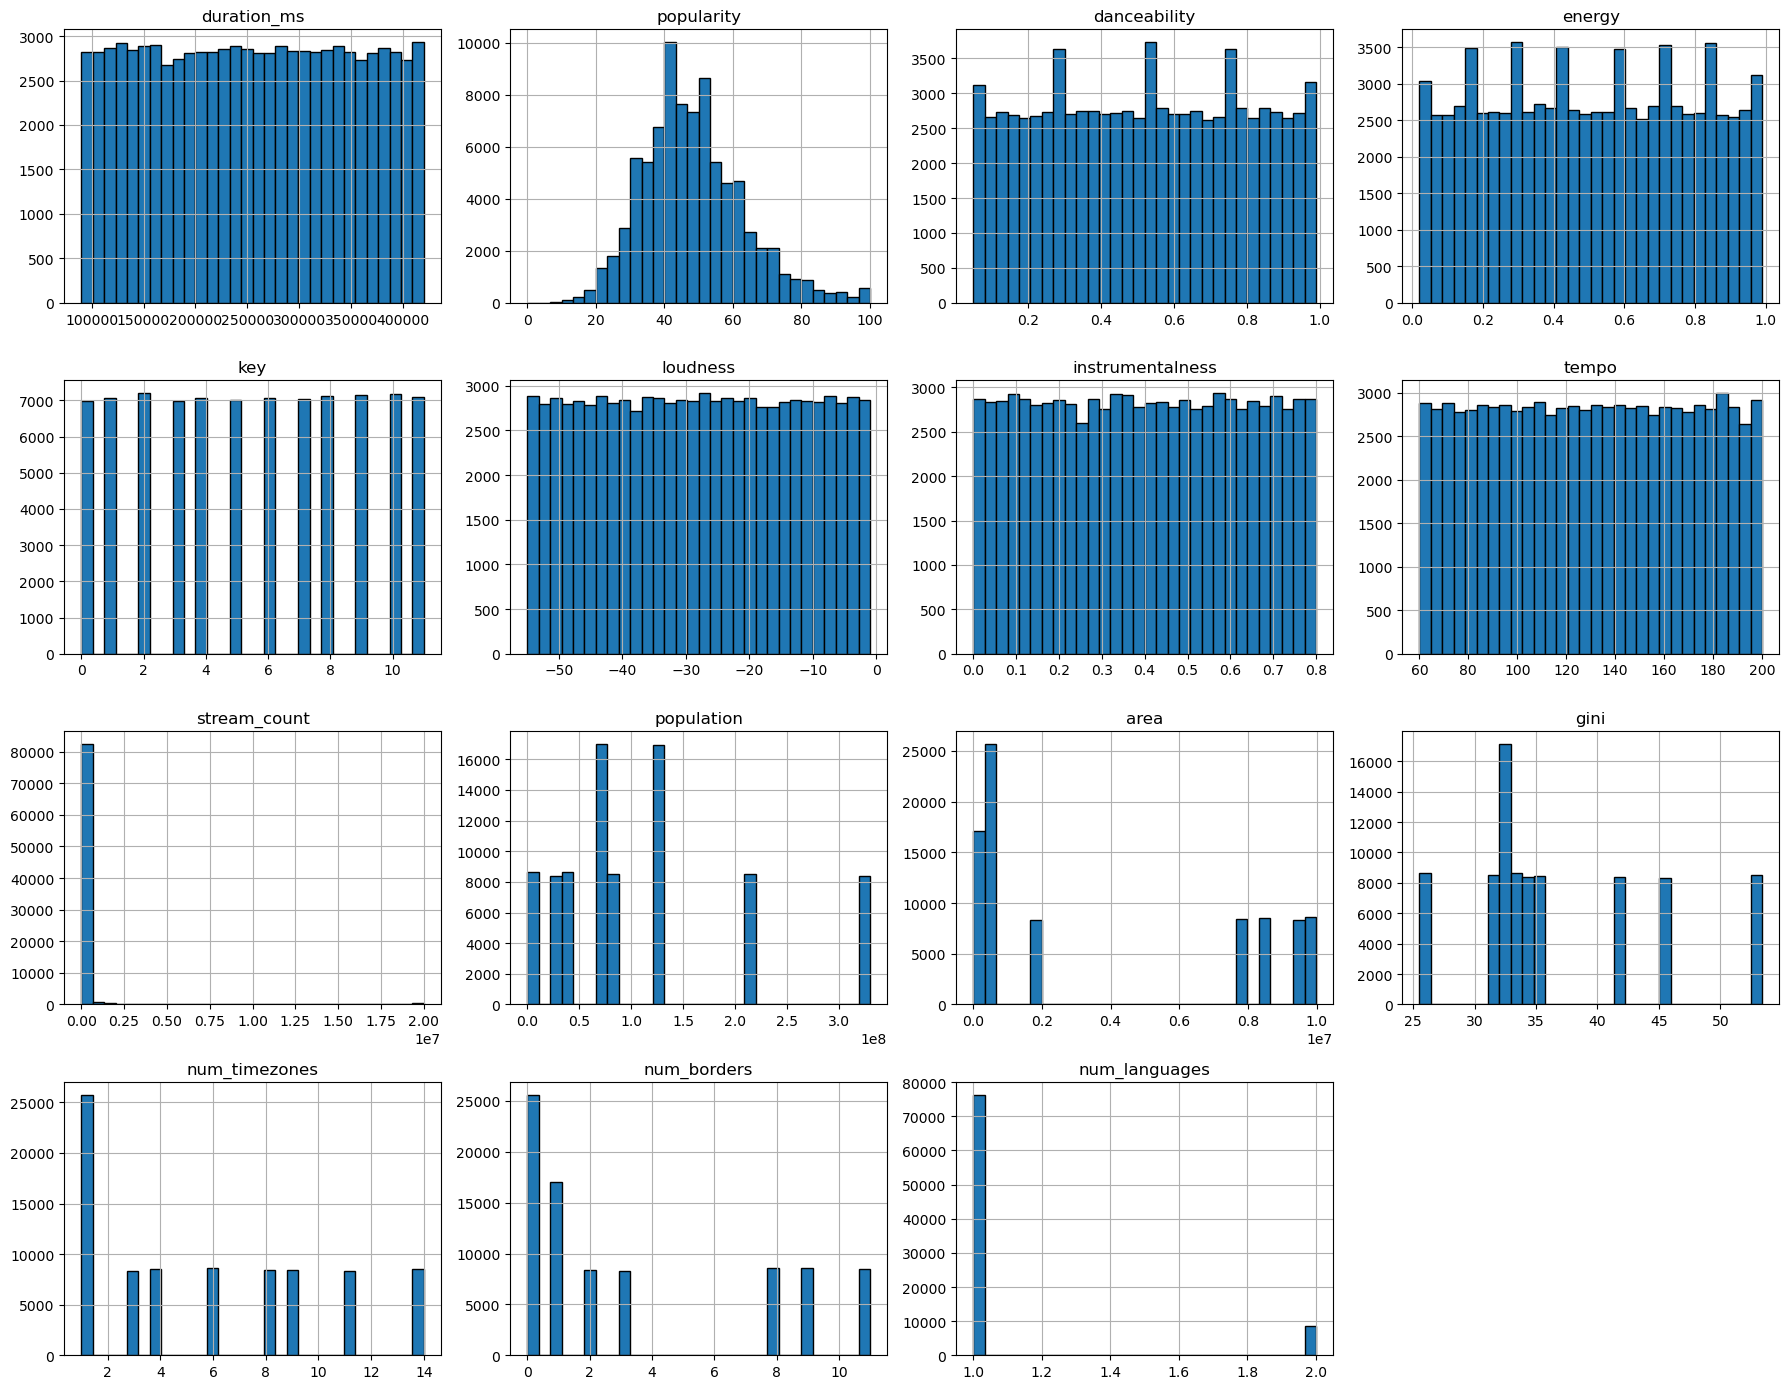

In [327]:
combined_df[num_cols].hist(
    bins=30,
    figsize=(18, 14),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

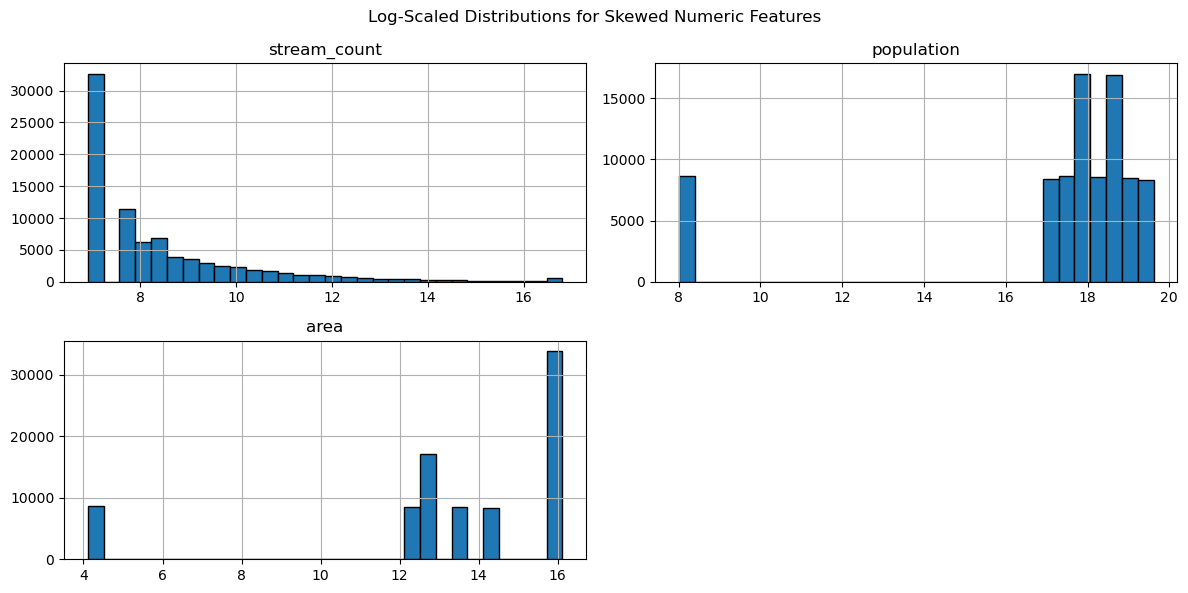

In [328]:
skewed_cols = ["stream_count", "population", "area"]

combined_df[skewed_cols].apply(lambda x: np.log1p(x)).hist(
    bins=30,
    figsize=(12, 6),
    edgecolor="black"
)

plt.suptitle("Log-Scaled Distributions for Skewed Numeric Features")
plt.tight_layout()
plt.show()

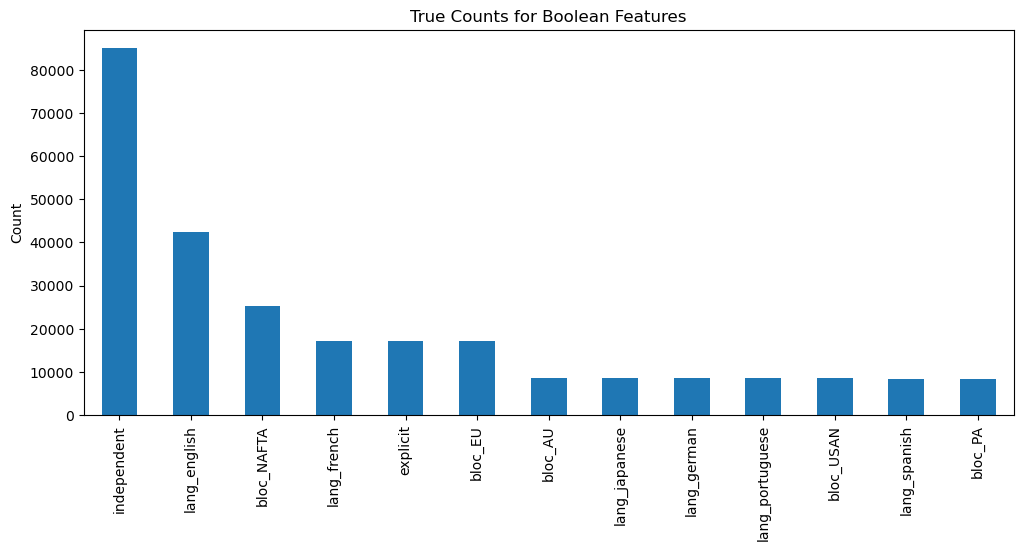

In [329]:
bool_cols = combined_df.select_dtypes(include="bool").columns

combined_df[bool_cols].sum().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("True Counts for Boolean Features")
plt.ylabel("Count")
plt.show()

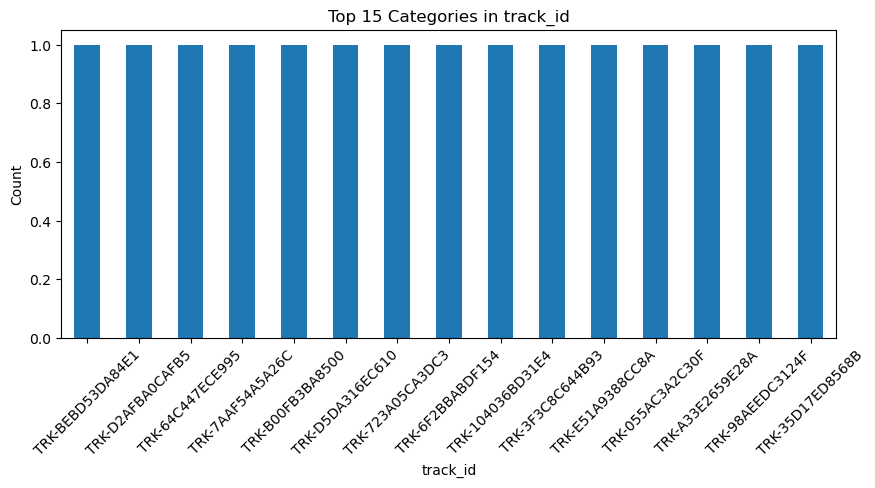

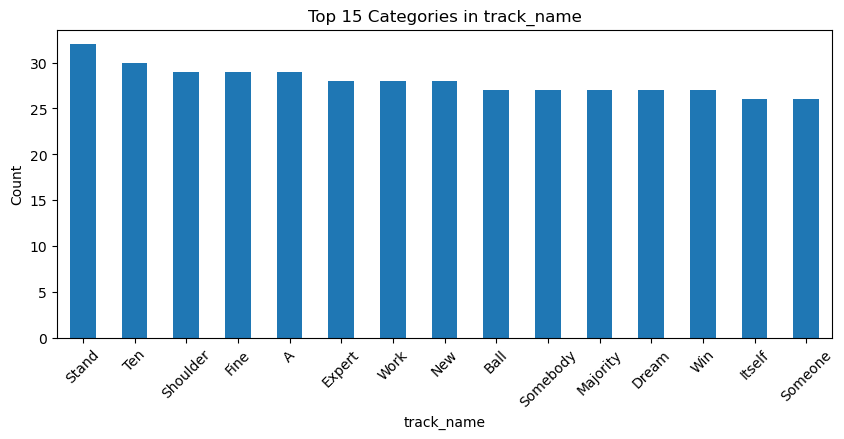

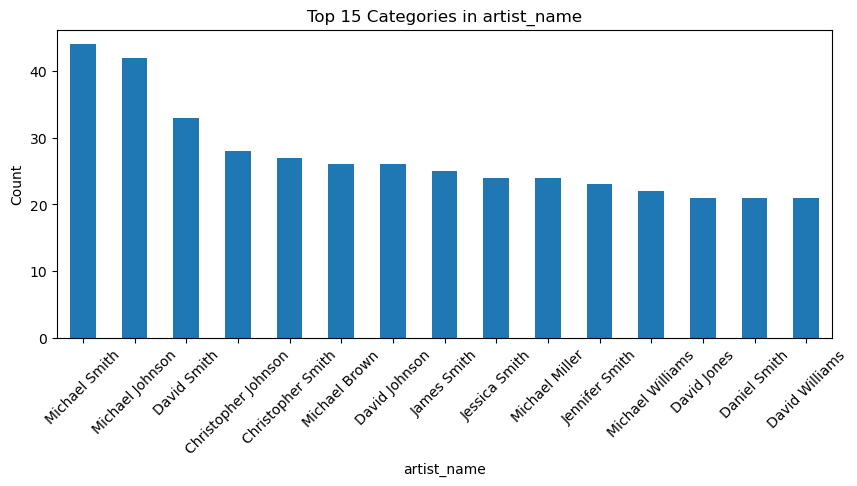

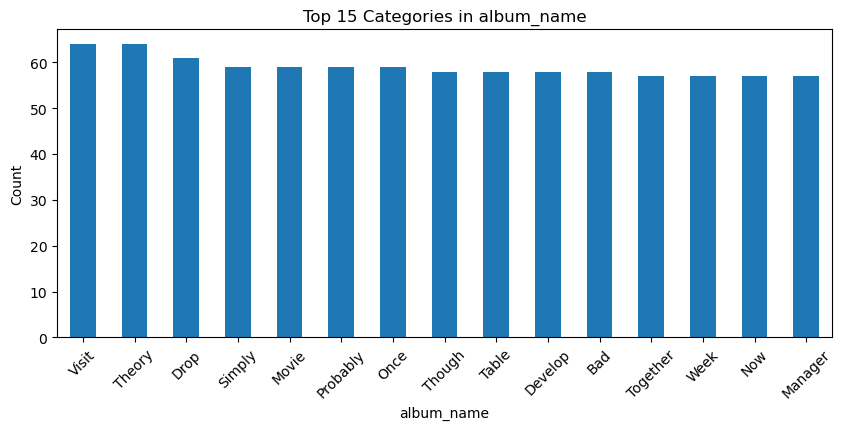

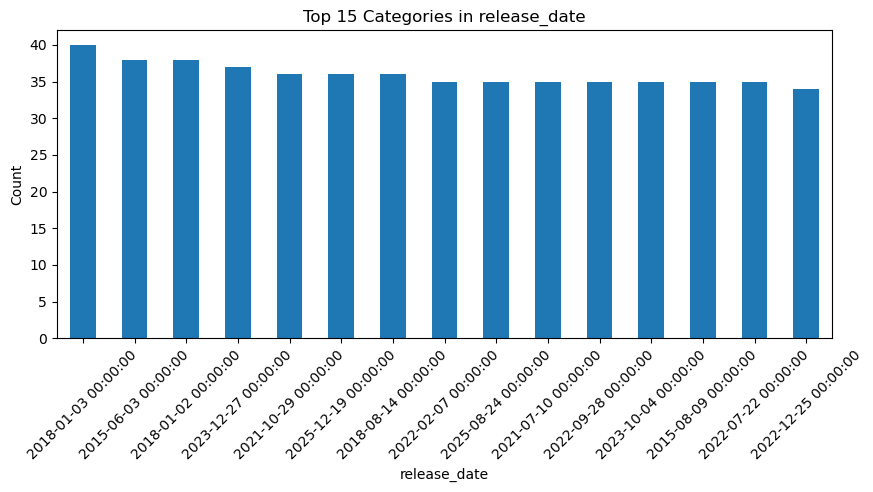

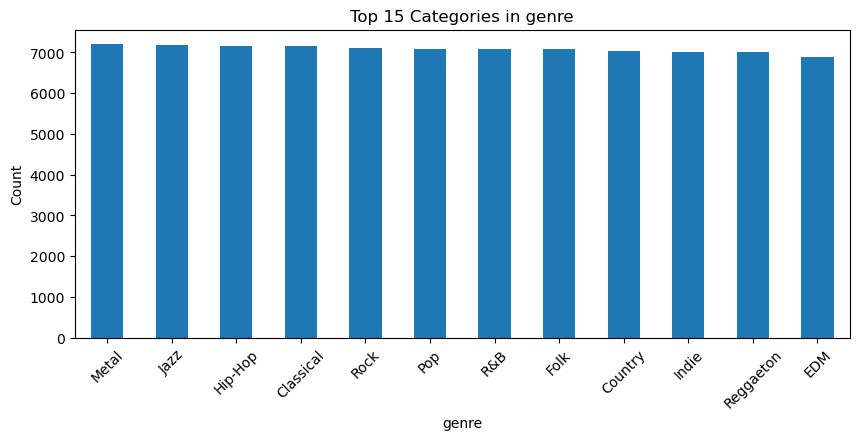

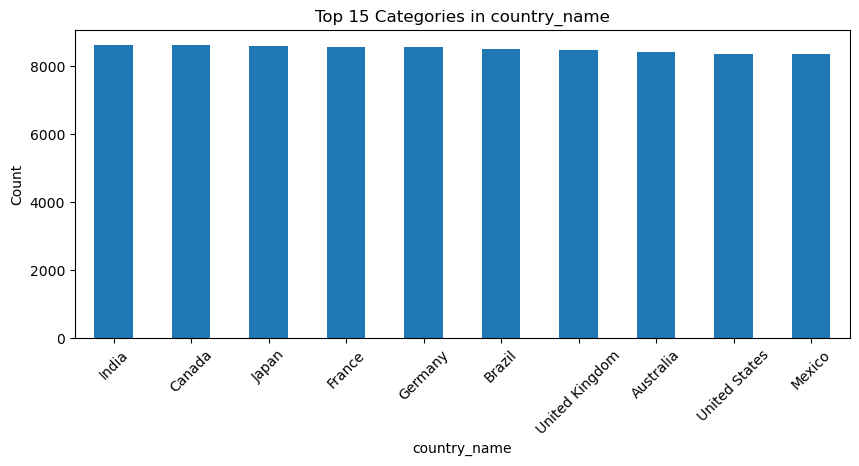

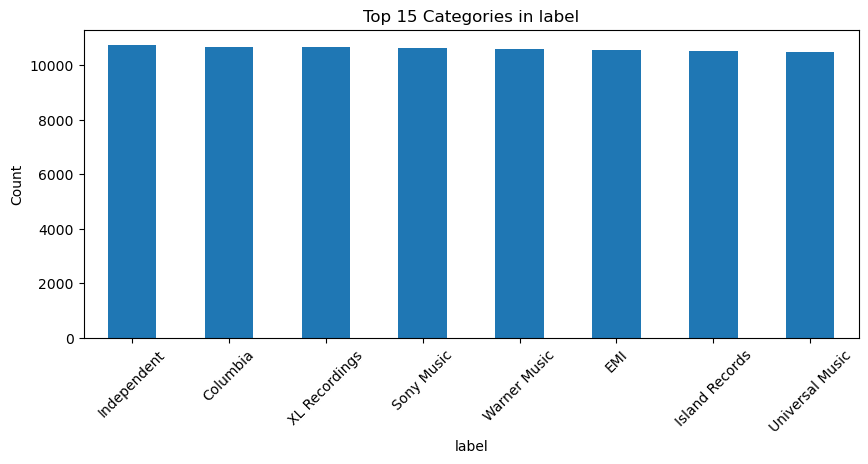

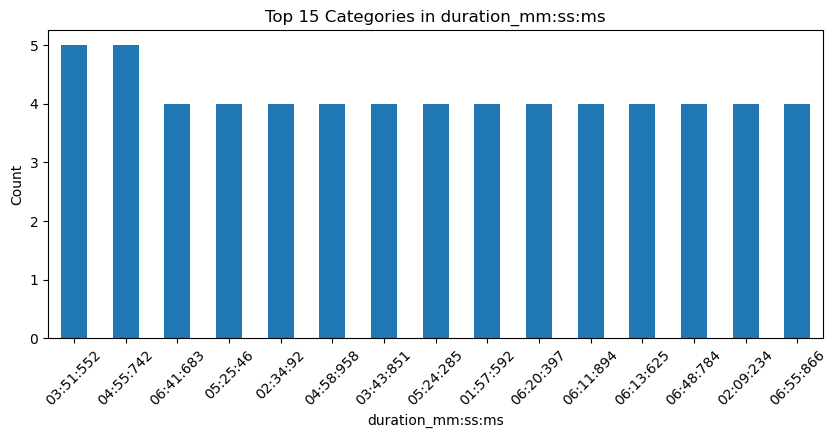

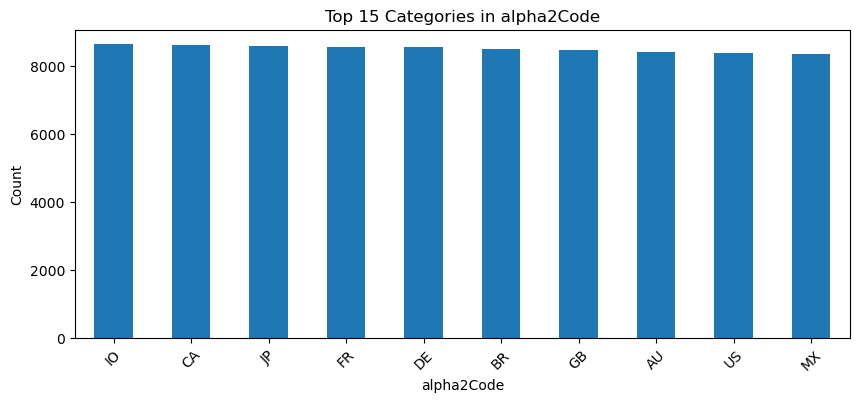

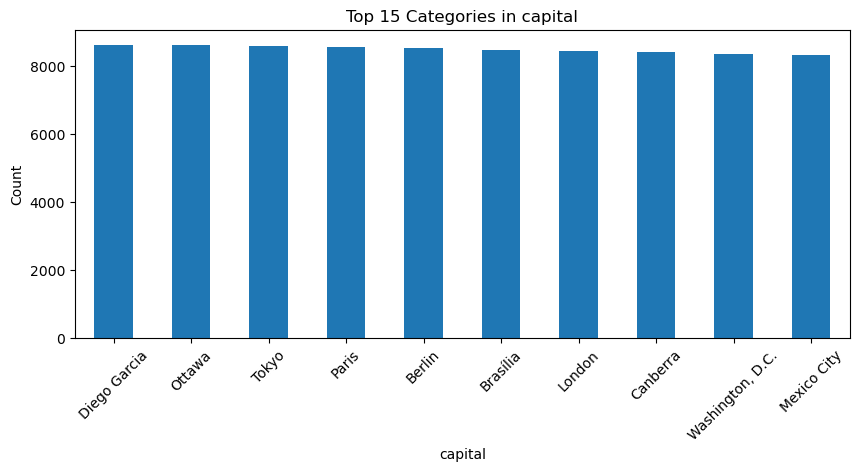

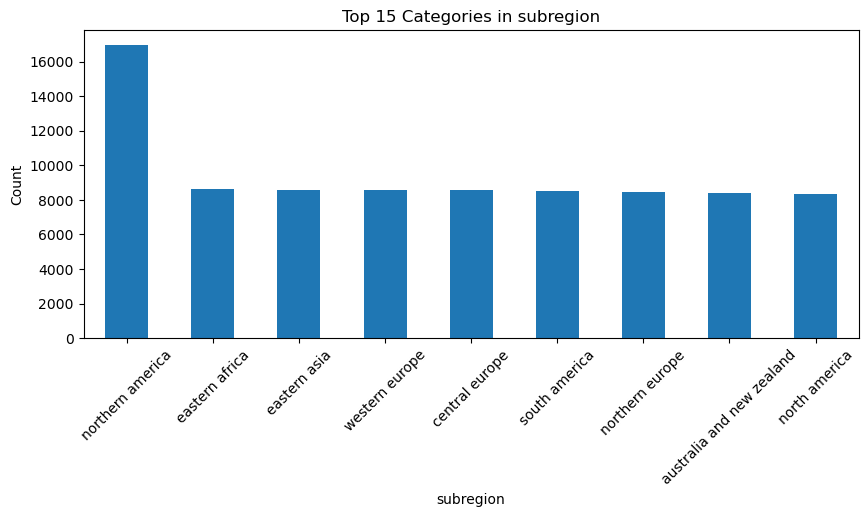

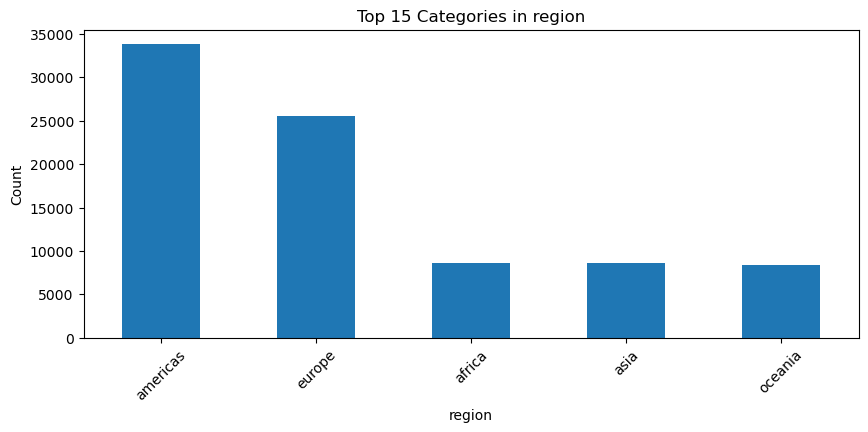

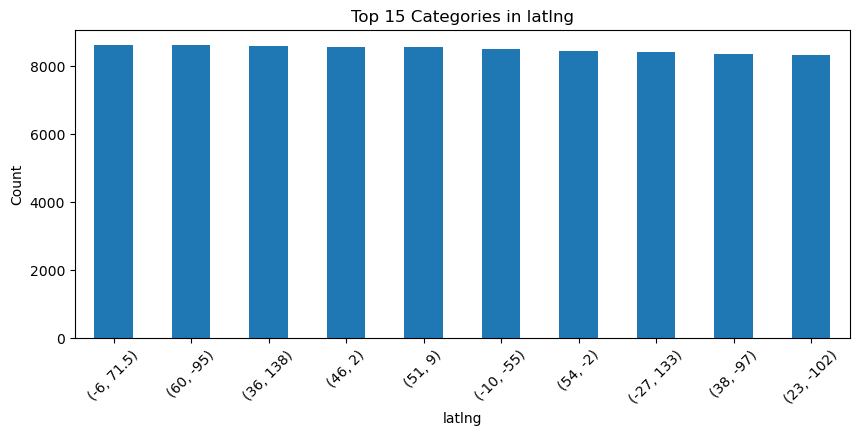

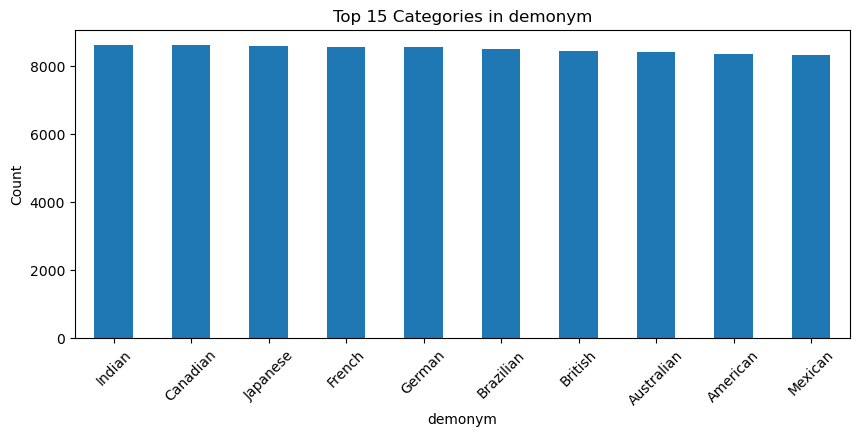

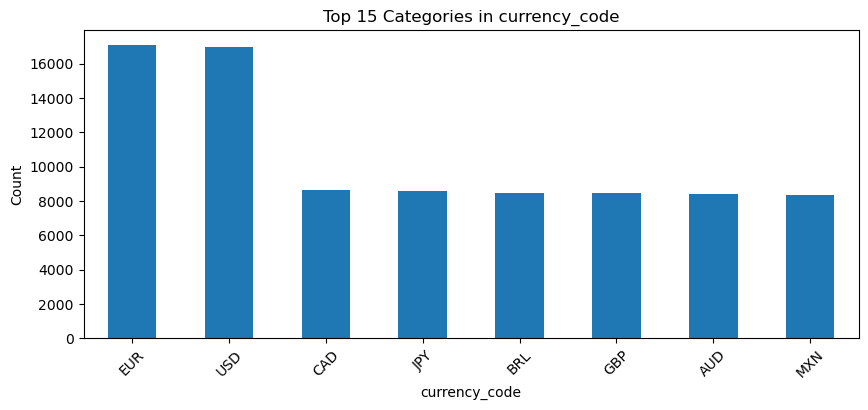

In [330]:
for col in cat_cols:
    if combined_df[col].nunique() > 2:
        combined_df[col].value_counts().head(15).plot(
            kind="bar",
            figsize=(10, 4)
        )
        plt.title(f"Top 15 Categories in {col}")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

### Artist Exploration

In [191]:
# Explore artists

artist_df = (
    combined_df
    .groupby('artist_name')
    .agg(
        num_songs=('track_id', 'count'),
        num_albums=('album_name', 'nunique'),
        mean_popularity=('popularity', 'mean'),
        median_popularity=('popularity', 'median'),
        total_streams=('stream_count', 'sum')
    )
    .reset_index()
)

In [340]:
artist_df.shape

(62364, 6)

In [192]:
artist_df.sort_values(by='num_songs', ascending=False).head(10)

,artist_name,num_songs,num_albums,mean_popularity,median_popularity,total_streams
42794,Michael Smith,44,44,50.704545,48.5,11585000
42517,Michael Johnson,42,41,49.214286,49.0,3577000
15690,David Smith,33,33,49.939394,50.0,961000
12082,Christopher Johnson,28,28,44.607143,40.5,515000
12302,Christopher Smith,27,27,50.407407,49.0,1598000
15469,David Johnson,26,26,47.000000,44.5,5058000
42256,Michael Brown,26,26,46.923077,46.5,280000
24699,James Smith,25,25,44.560000,41.0,389000
42624,Michael Miller,24,24,45.333333,47.0,689000
27989,Jessica Smith,24,24,46.833333,41.0,3381000


Text(0, 0.5, 'Artists')

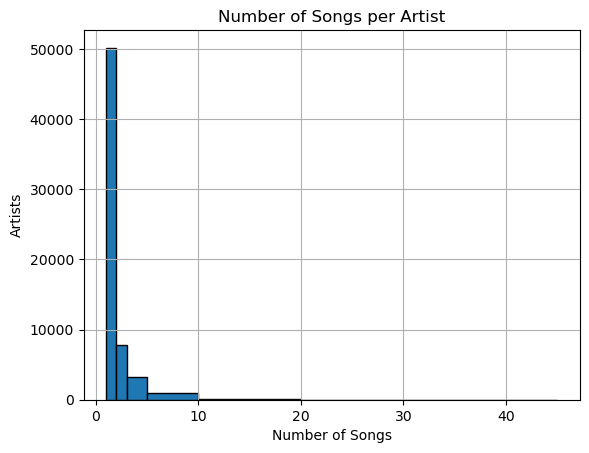

In [223]:
bins = [1, 2, 3, 5, 10, 20, 30, 40, 45]

artist_df["num_songs"].hist(bins=bins, edgecolor="black")
plt.title("Number of Songs per Artist")
plt.xlabel("Number of Songs")
plt.ylabel("Artists")

Text(0, 0.5, 'Artists')

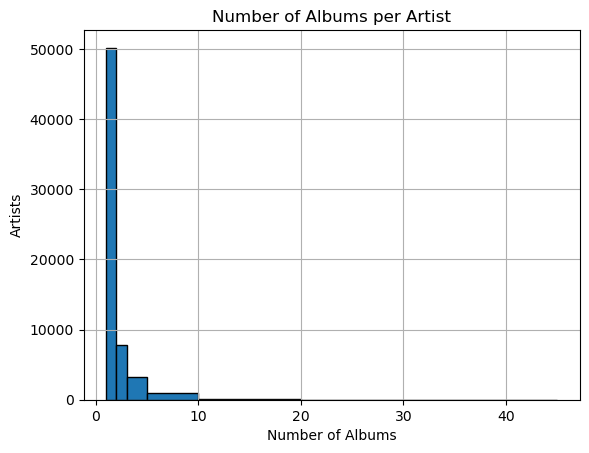

In [224]:
bins = [1, 2, 3, 5, 10, 20, 30, 40, 45]

artist_df["num_albums"].hist(bins=bins, edgecolor="black")
plt.title("Number of Albums per Artist")
plt.xlabel("Number of Albums")
plt.ylabel("Artists")

Interesting insight - The number of albums per artist looks identical to the number of songs per artist, indicating that the majority of songs are relased individually.

In [193]:
artist_df.sort_values(by='mean_popularity', ascending=False).head(30)

,artist_name,num_songs,num_albums,mean_popularity,median_popularity,total_streams
46066,Nicholas Graham,1,1,100.0,100.0,14458000
58190,Thomas Park,1,1,100.0,100.0,20000000
22635,Harold Price,1,1,100.0,100.0,20000000
38645,Luis Waters,1,1,100.0,100.0,1708000
28522,Jodi Bishop,1,1,100.0,100.0,20000000
19472,Elizabeth Stanley,1,1,100.0,100.0,8383000
25095,Janet Ross,1,1,100.0,100.0,4952000
6646,Bobby Gomez,1,1,100.0,100.0,20000000
21985,Glenn Murphy,1,1,100.0,100.0,20000000
55217,Stanley Baldwin,1,1,100.0,100.0,20000000


In [194]:
artist_df.sort_values(by='total_streams', ascending=False).head(30)

,artist_name,num_songs,num_albums,mean_popularity,median_popularity,total_streams
4792,Anthony Walker,5,5,62.400000,46.0,40008000
48078,Peter Hall,3,3,71.666667,90.0,34132000
49081,Rebecca Brown,9,9,60.333333,50.0,27892000
35203,Kimberly Smith,12,12,59.750000,57.0,26801000
25664,Jason Owens,4,4,61.250000,60.5,25351000
52075,Samantha Johnson,6,6,58.500000,48.5,24405000
9004,Caitlin Smith,2,2,89.000000,89.0,24327000
55447,Stephanie Lee,6,6,70.666667,73.5,24221000
2086,Amanda Henry,6,6,65.666667,57.0,21858000
59146,Todd Rodriguez,2,2,86.500000,86.5,21802000


An interesting insight came from exploring the Artist Data Frame. This data has a columns showing the mean and median popularity for each artist - surprisingly there are more than 30 artists with a perfect 100 popularity score for both mean and median, which also may be due to many artists having only 1 song. However, when inspecting the top 30 total streamed, none of the artists have a mean or median popularity score of 100. We need to inspect further to determine if popularity is acutually the best column to use as our target data. Stream Count could be a better primary target feature to focus on for musicians and labels.

Let's inspect this information in the combined dataframe.

In [196]:
combined_df[['track_name', 'artist_name', 'album_name', 'popularity', 'stream_count']].sort_values(by='popularity', ascending=False).head(20)

,track_name,artist_name,album_name,popularity,stream_count
83048,Professor free,Kathy Mcconnell,My answer,100,9150000
2748,Front sure capital how,Marissa Green,Yeah,100,20000000
29249,President production both,Justin Sanders,Hand huge,100,8524000
73145,This coach,Jason Ewing,Picture them,100,4528000
38411,Day cut maintain second,John Hughes,Example,100,20000000
64723,Place resource gas camera,Pamela Graham,For military,100,20000000
71742,Collection,Alicia Arnold,Think,100,7249000
76999,Me thank,Jacob Townsend,Early mean,100,20000000
47497,Relationship,Nichole Lawson,Capital,100,20000000
78057,Represent public,Christopher Jones,West,100,7368000


In [198]:
combined_df[['track_name', 'artist_name', 'album_name', 'popularity', 'stream_count']].sort_values(by='stream_count', ascending=False).head(20)

,track_name,artist_name,album_name,popularity,stream_count
40577,Conference read you experience,Amy Shepherd,Young rule,100,20000000
60390,Million side,Nicholas Fowler,Second,99,20000000
84283,Recognize fly,Allison Hale,Get meeting,96,20000000
29859,It gas,Daniel Lewis,Order,97,20000000
48812,Camera,Stephanie Roach,Drop,93,20000000
60004,List,Caitlin Smith,Listen,100,20000000
29697,Only address,Manuel Yang,Hope current,97,20000000
74897,Tend scientist,Lauren Roberts,Teacher these,89,20000000
74829,Place piece,Tracy Pope,Yard,87,20000000
74801,Parent of teach,Cindy Figueroa,Religious spring,85,20000000


Exploring the main data set, we can see that the stream count clearly has a miximum of 20 million streams. There are more than 30 records with 20 mil streams listed, and several have a popularity score of 100, but there are also many with a maxed out stream count that do not have a perfect 100 popularity score. This tells us that number of stream counts is not the only factor taken into account to determine the popularity score, so it is still the best for our primary target feature. However stream count can still be very useful marketing and budget information for artists and labels, so it will be a strong secondary target feature.

### Label Exploration

In [261]:
label_df = (
    combined_df
    .groupby('label')
    .agg(
        num_artists=('artist_name', 'count'),
        num_songs=('track_id', 'count'),
        num_albums=('album_name', 'nunique'),
        mean_popularity=('popularity', 'mean'),
        median_popularity=('popularity', 'median'),
        total_streams=('stream_count', 'sum')
    )
    .reset_index()
)

In [343]:
label_df['stream_count_rank'] = label_df['total_streams'].rank(method='min', ascending=False).astype(int)
label_df['num_artist_Rank'] = label_df['num_artists'].rank(method='min', ascending=False).astype(int)
label_df['num_songs_rank'] = label_df['num_albums'].rank(method='min', ascending=False).astype(int)
label_df['mean_pop_rank'] = label_df['mean_popularity'].rank(method='min', ascending=False).astype(int)

In [344]:
label_df.sort_values(by='mean_popularity', ascending=False)

,label,num_artists,num_songs,num_albums,mean_popularity,median_popularity,total_streams,stream_count_rank,num_artist_Rank,num_songs_rank,mean_pop_rank
4,Sony Music,10620,10620,6324,48.322693,47.0,2419227000,2,4,5,1
1,EMI,10572,10572,6376,48.307037,47.0,2451406000,1,6,3,2
2,Independent,10763,10763,6388,48.260894,47.0,2383638000,3,1,2,3
7,XL Recordings,10684,10684,6481,48.210876,47.0,2103647000,8,3,1,4
5,Universal Music,10496,10496,6260,48.207508,47.0,2276440000,4,8,7,5
0,Columbia,10685,10685,6371,48.090220,46.0,2162393000,7,2,4,6
3,Island Records,10519,10519,6299,48.005609,46.0,2179477000,6,7,6,7
6,Warner Music,10615,10615,6238,47.901083,46.0,2242179000,5,5,8,8


There are 8 total labels that represent all of the artists and songs in the data set. When ranking the lables on the most stream count, number of artists they represent, and number of songs, we see that there is not one label that ranks highest on all three. This indicates that there is not a dominant label that produces the most popular songs all of the time.

### Song Exploration

In [211]:
# What are the top songs with a perfect 100 popularity score and 2 Mil Streams?

condition1 = combined_df['popularity'] == 100
condition2 = combined_df['stream_count'] == 20000000
combined_conditions = condition1 & condition2

Top_Songs = combined_df[combined_conditions]
print(f"There are {len(Top_Songs)} songs with a popularity score of 100 and 20,000,000 streams")
print(f"There are {Top_Songs['artist_name'].nunique()} artists who have at least one song with a popularity score of 100 and 20,000,000 streams")

There are 201 songs with a popularity score of 100 and 20,000,000 streams
There are 201 artists who have at least one song with a popularity score of 100 and 20,000,000 streams


Another interesting insight from exploring the top songs - there are no artists that have more than 1 song that is the top in both popularity and stream_count. How does this compare to our full dataset?

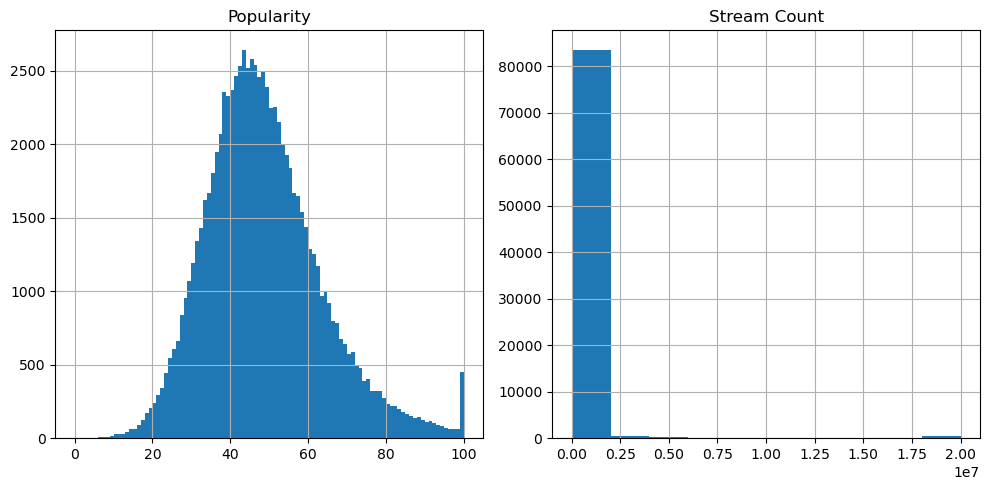

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

combined_df.hist('popularity', bins=100, ax=axes[0])
combined_df.hist('stream_count', bins=10, ax=axes[1])

axes[0].set_title("Popularity")
axes[1].set_title("Stream Count")

plt.tight_layout()
plt.show()

When visualizing the distributions of <strong>Popularity</strong> and <strong>Stream Count</strong>, we see that Popularity is normally distributed with an additional spike at 100, whereas Stream Count is heavily right skewed indicating that the vast majority of songs have a stream count of less than 2.5 Million. We know the maxmimum stream count is 20 Million, so to more accurately compare the relationship between these two we need to use a logrithmic scale for stream count.

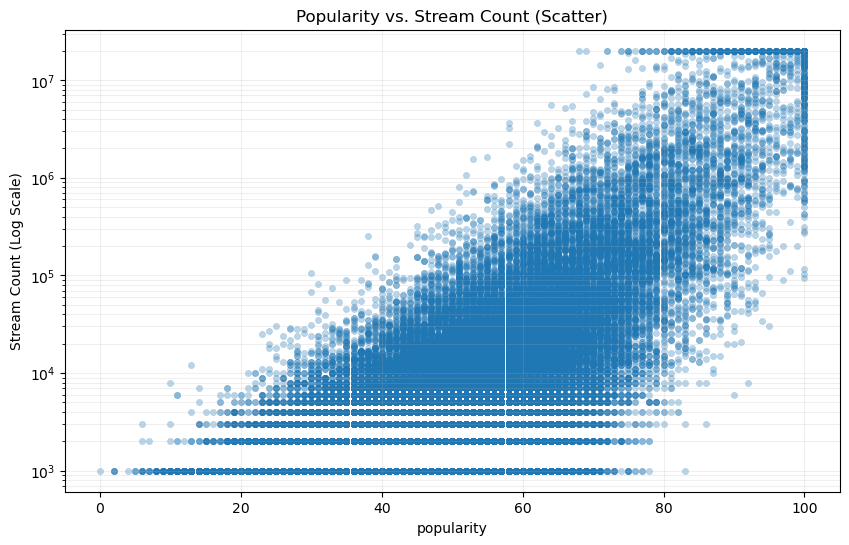

In [259]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_df, 
    x='popularity', 
    y='stream_count', 
    alpha=0.3,
    edgecolor=None,
    s=20
)

plt.yscale('log')
plt.title('Popularity vs. Stream Count (Scatter)')
plt.ylabel('Stream Count (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In this scatter plot we can see the relationship between popularity and stream count shows a positive correlation as expected. We can also see some unexpected groupings showing that popularity scores of 100 have a wide range of stream counts, but do not drop below 100,000, and stream counts maxed at 20 million do not drop below popularity scores of approximately 65.

In [345]:
analysis_date = combined_df["release_date"].max()

combined_df["days_since_release"] = (
    analysis_date - combined_df["release_date"]
).dt.days

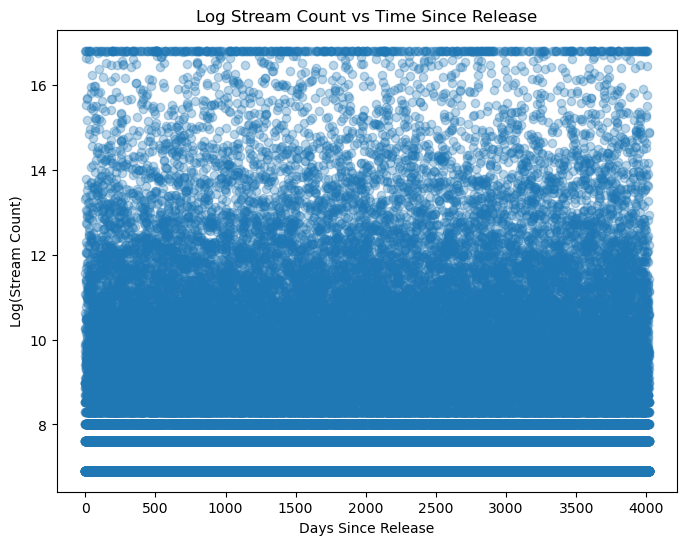

In [347]:
plt.figure(figsize=(8, 6))
plt.scatter(
    combined_df["days_since_release"],
    np.log1p(combined_df["stream_count"]),
    alpha=0.3
)
plt.xlabel("Days Since Release")
plt.ylabel("Log(Stream Count)")
plt.title("Log Stream Count vs Time Since Release")
plt.show()


In [348]:
combined_df["streams_per_day"] = (
    combined_df["stream_count"] / combined_df["days_since_release"].clip(lower=1)
)

In [356]:
combined_df[['track_name','artist_name','streams_per_day','release_date','stream_count','popularity']].sort_values(by='streams_per_day', ascending=False).head(10)

,track_name,artist_name,streams_per_day,release_date,stream_count,popularity
79818,Light would,Glenn Murphy,1.000000e+07,2025-12-29,20000000,100
61906,Federal floor,Melissa Hansen,5.673667e+06,2025-12-28,17021000,87
34631,Base,Anthony Walker,5.000000e+06,2025-12-27,20000000,92
6465,Would exactly between mind,Anita Torres,4.000000e+06,2025-12-26,20000000,91
63960,Special,Kimberly James,1.112600e+06,2025-12-26,5563000,100
14195,Who treat technology around response,Johnny Steele,1.000000e+06,2025-12-11,20000000,100
79908,Those know star,Ruben Williamson,8.000000e+05,2025-12-06,20000000,88
76485,Yourself act,Mr. Walter Sullivan MD,7.142857e+05,2025-12-03,20000000,100
47532,Tell rest avoid probably,Kimberly Bowman,6.802500e+05,2025-12-07,16326000,96
75220,Spring support over,William Anderson,6.250000e+05,2025-11-29,20000000,98


### Genre Exploration

In [274]:
combined_df['genre'].nunique()

12

In [275]:
genre_df = (
    combined_df
    .groupby('genre')
    .agg(
        num_songs=('track_id', 'count'),
        num_artists=('artist_name', 'count'),
        num_albums=('album_name', 'nunique'),
        mean_popularity=('popularity', 'mean'),
        median_popularity=('popularity', 'median'),
        total_streams=('stream_count', 'sum')
    )
    .reset_index()
)

In [280]:
genre_df['num_songs_rank'] = genre_df['num_songs'].rank(method='min', ascending=False).astype(int)
genre_df['num_artists_rank'] = genre_df['num_artists'].rank(method='min', ascending=False).astype(int)
genre_df['mean_pop_rank'] = genre_df['mean_popularity'].rank(method='min', ascending=False).astype(int)
genre_df['median_pop_rank'] = genre_df['median_popularity'].rank(method='min', ascending=False).astype(int)
genre_df['total_stream_rank'] = genre_df['total_streams'].rank(method='min', ascending=False).astype(int)

In [283]:
genre_df.sort_values(by='mean_pop_rank', ascending=True)

,genre,num_songs,num_artists,num_albums,mean_popularity,median_popularity,total_streams,num_songs_rank,num_artists_rank,mean_pop_rank,total_stream_rank
8,Pop,7088,7088,4498,48.375564,47.0,1538132000,6,6,1,6
9,R&B,7080,7080,4550,48.364972,47.0,1624312000,7,7,2,2
0,Classical,7154,7154,4641,48.364971,47.0,1558455000,4,4,3,4
4,Hip-Hop,7156,7156,4557,48.360257,47.0,1906753000,3,3,4,1
2,EDM,6885,6885,4433,48.208424,47.0,1532953000,12,12,5,7
7,Metal,7198,7198,4565,48.192276,47.0,1604970000,1,1,6,3
1,Country,7027,7027,4462,48.170912,46.0,1440463000,9,9,7,10
5,Indie,7001,7001,4475,48.125982,47.0,1257966000,10,10,8,12
3,Folk,7078,7078,4493,48.096779,47.0,1538901000,8,8,9,5
11,Rock,7110,7110,4553,47.968354,46.0,1452050000,5,5,10,8


Once again we find that the popularity score and total number of streams do not align. In the Genre Data Frame we can see that the pop genre is the most popular but is the 6th most streamed whereas the hip hop genre is the most streamed but is the 4th highest popular. While this may seem at first glance as misleading, it actually indicates that there are other features that contribute to the ultimate popularity and success of a song. When we show the data on a scatter plot (below) with the hue set to genres we can easily see that there is no visable pattern or clusters for genre, and each genre has a wide distribution of popularity and stream count.

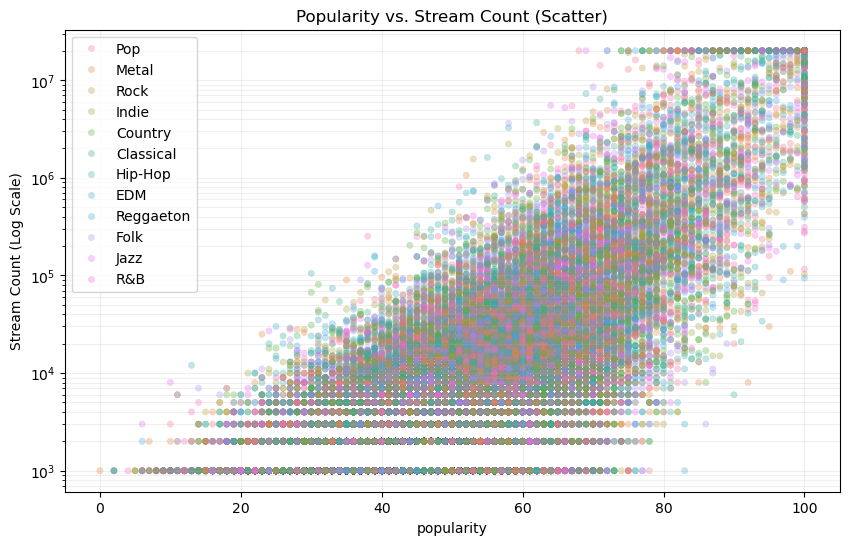

In [285]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_df, 
    x='popularity', 
    y='stream_count',
    hue='genre',
    alpha=0.3,
    edgecolor=None,
    s=20
)

plt.yscale('log')
plt.title('Popularity vs. Stream Count (Scatter)')
plt.ylabel('Stream Count (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### Region/Country

In [305]:
combined_df.groupby("region")["popularity"].mean().sort_values(ascending=False)

region
asia        48.349959
europe      48.276260
americas    48.098849
oceania     48.048287
africa      48.008929
Name: popularity, dtype: float64

In [361]:
combined_df.groupby("region")["stream_count"].mean().sort_values(ascending=False)

region
asia        234572.427456
europe      221648.559800
americas    211246.885081
africa      208339.285714
oceania     191179.590866
Name: stream_count, dtype: float64

In [306]:
combined_df.groupby("country_name")["popularity"].mean().sort_values(ascending=False)

country_name
United Kingdom    48.409419
Japan             48.349959
France            48.341478
Brazil            48.316993
Germany           48.079326
Canada            48.061753
United States     48.059133
Australia         48.048287
India             48.008929
Mexico            47.954884
Name: popularity, dtype: float64

In [360]:
combined_df.groupby("country_name")["stream_count"].mean().sort_values(ascending=False)

country_name
Japan             234572.427456
France            230154.430676
Mexico            227574.154068
United Kingdom    221204.709502
Canada            217715.264074
Germany           213574.587575
India             208339.285714
Brazil            206760.900306
United States     192845.104142
Australia         191179.590866
Name: stream_count, dtype: float64

<Axes: title={'center': 'popularity'}, xlabel='country_name'>

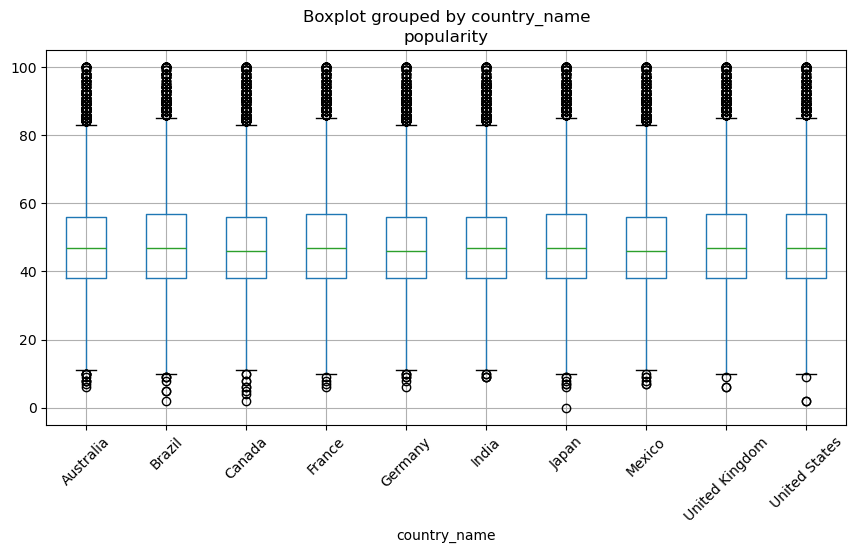

In [304]:
combined_df.boxplot(
    column="popularity",
    by="country_name",
    rot=45,
    figsize=(10, 5)
)


## Correlation Analysis

In [308]:
num_cols

Index(['duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'instrumentalness', 'tempo', 'stream_count', 'population',
       'area', 'gini', 'num_timezones', 'num_borders', 'num_languages'],
      dtype='object')

In [321]:
cat_cols

Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_date',
       'genre', 'mode', 'country_name', 'explicit', 'label',
       'duration_mm:ss:ms', 'alpha2Code', 'capital', 'subregion', 'region',
       'latlng', 'demonym', 'independent', 'lang_english', 'lang_french',
       'lang_german', 'lang_japanese', 'lang_portuguese', 'lang_spanish',
       'currency_code', 'bloc_AU', 'bloc_EU', 'bloc_NAFTA', 'bloc_PA',
       'bloc_USAN'],
      dtype='object')

### Numerical Feature Correlation

In [362]:
num_cols = combined_df.select_dtypes(include=np.number).columns

In [363]:
num_cols

Index(['duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'instrumentalness', 'tempo', 'stream_count', 'population',
       'area', 'gini', 'num_timezones', 'num_borders', 'num_languages',
       'days_since_release', 'streams_per_day'],
      dtype='object')

In [364]:
corr_matrix = combined_df[num_cols].corr()
corr_matrix['popularity'].sort_values(ascending=False)

popularity            1.000000
stream_count          0.357563
streams_per_day       0.040876
loudness              0.003242
danceability          0.003227
num_timezones         0.003093
num_borders           0.002845
instrumentalness      0.002093
gini                  0.001062
population            0.000777
energy               -0.000318
duration_ms          -0.000506
num_languages        -0.002303
tempo                -0.002734
area                 -0.002872
key                  -0.003242
days_since_release   -0.004373
Name: popularity, dtype: float64

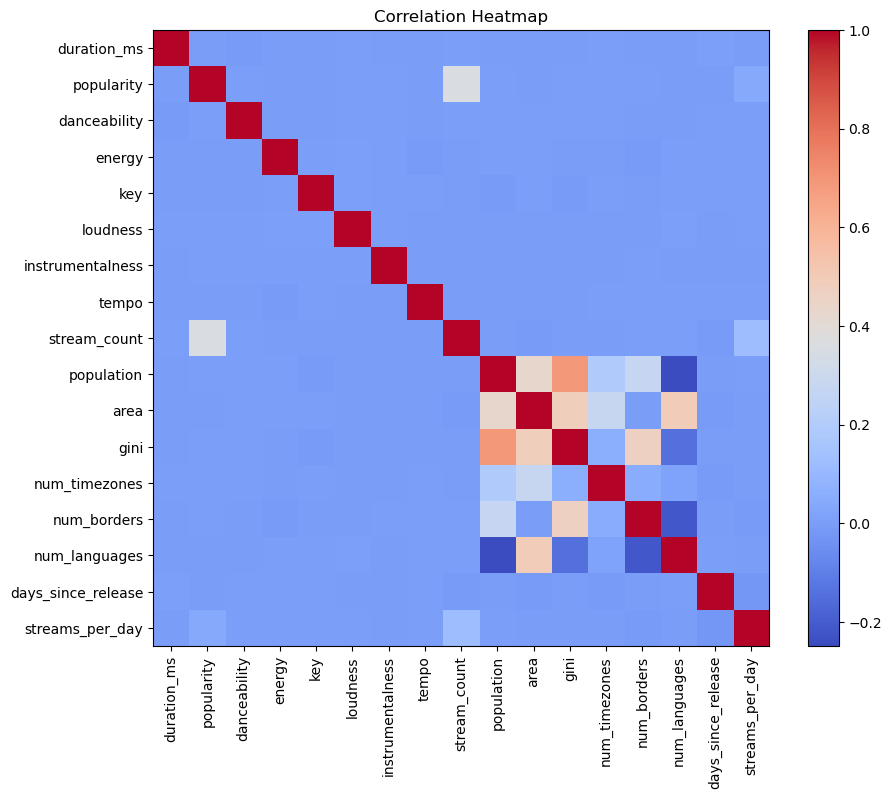

In [365]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap")
plt.show()

The Pearson corrleation analysis of numeric features shows that no single numeric feature has a strong linear relationship with track popularity, with the exception of stream count which is our other target feature. This suggests that the track popularity is not driven by simple linear effects, and is more likely influenced by non-linear interactions, aggregation-level effects, and/or possibly categorical features.

### Categorical Feature Correlation

In [322]:
for col in cat_cols:
    if combined_df[col].apply(lambda x: isinstance(x, list)).any():
        combined_df[col] = combined_df[col].apply(tuple)

In [323]:
binary_cat_cols = [
    col for col in cat_cols
    if combined_df[col].nunique() == 2
]

multi_cat_cols = [
    col for col in cat_cols
    if combined_df[col].nunique() > 2
]

In [324]:
for col in binary_cat_cols:
    print(f"\n{col.upper()}")
    display(
        combined_df.groupby(col)["popularity"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )



MODE


,mean,median,count
mode,,,
minor,48.186124,47.0,42461
major,48.140776,46.0,42493



EXPLICIT


,mean,median,count
explicit,,,
False,48.169973,47.0,67852
True,48.137528,47.0,17102



LANG_ENGLISH


...

,mean,median,count
bloc_NAFTA,,,
False,48.221874,47.0,59651
True,48.025689,46.0,25303



BLOC_PA


,mean,median,count
bloc_PA,,,
False,48.186126,47.0,76620
True,47.954884,46.0,8334



BLOC_USAN


,mean,median,count
bloc_USAN,,,
True,48.316993,47.0,8486
False,48.146401,47.0,76468


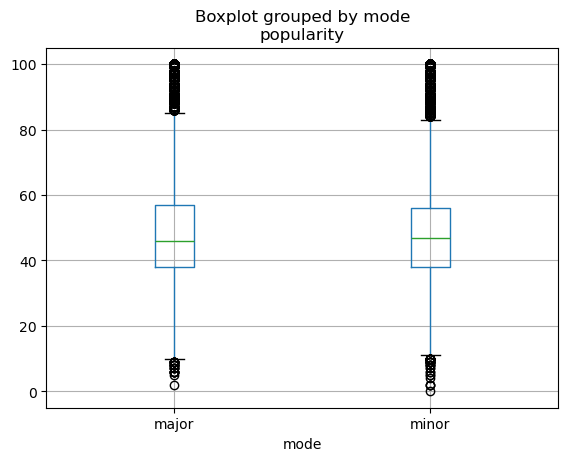

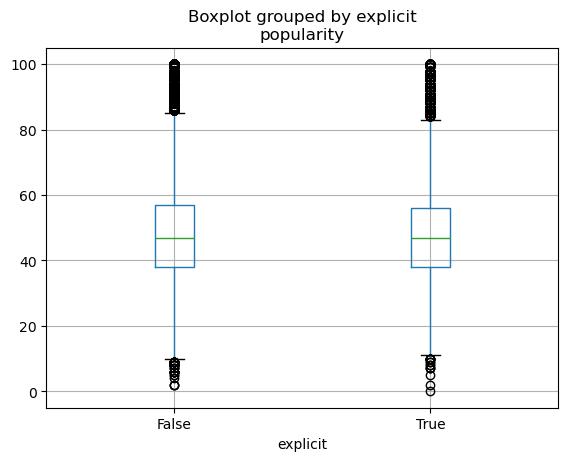

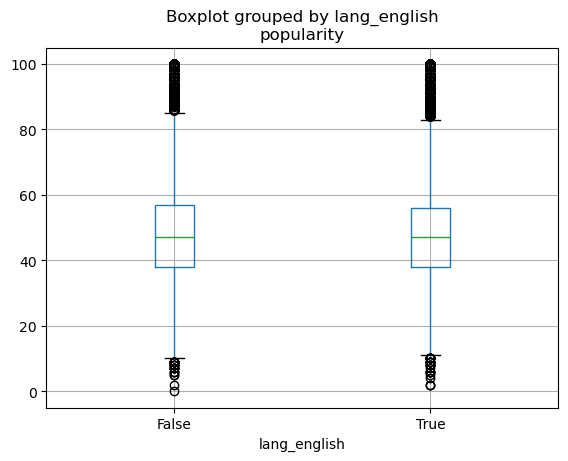

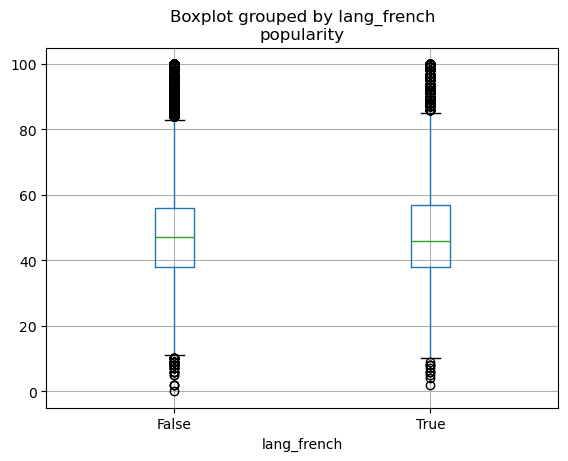

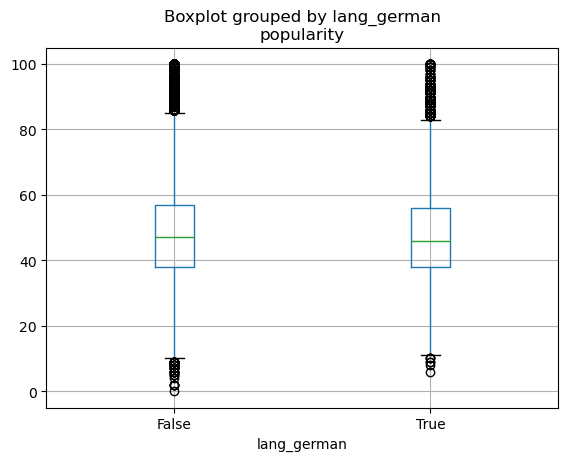

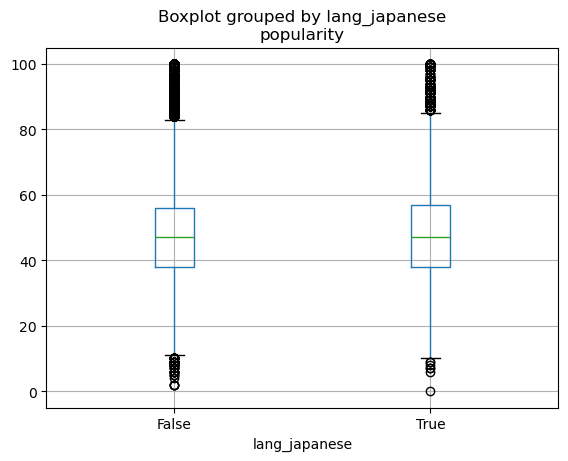

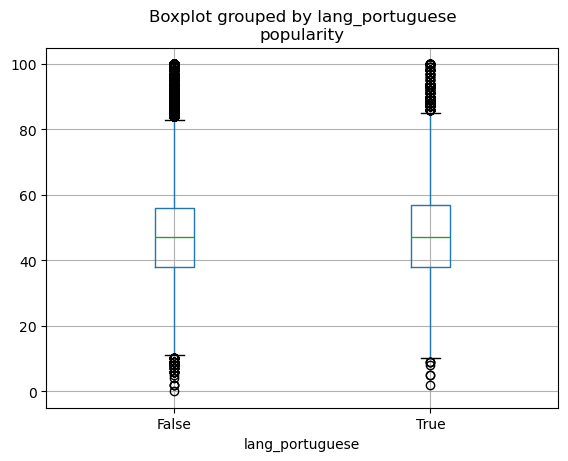

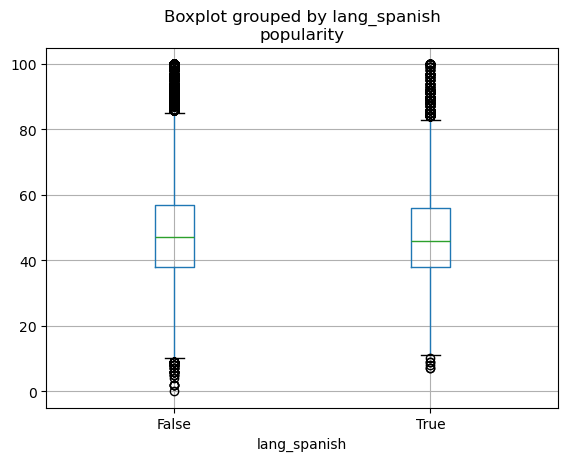

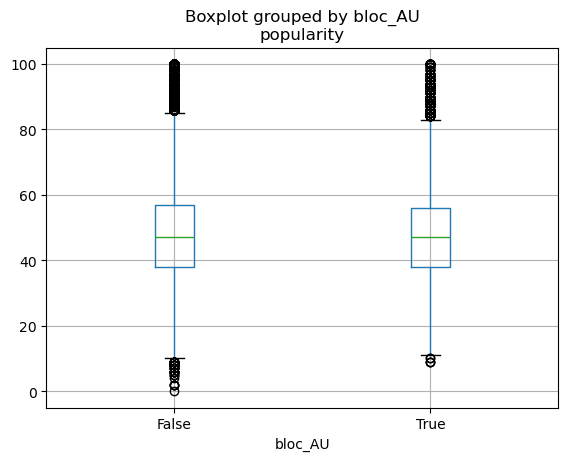

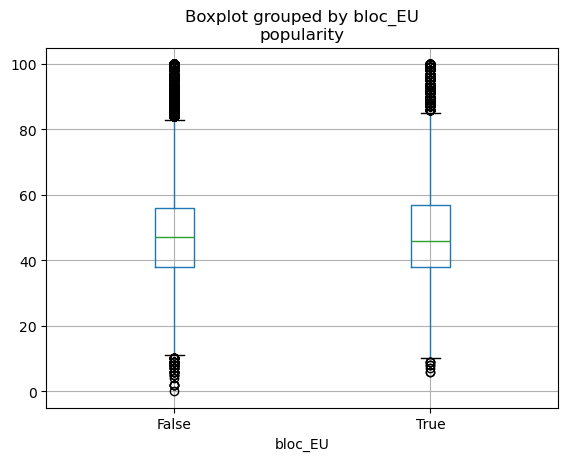

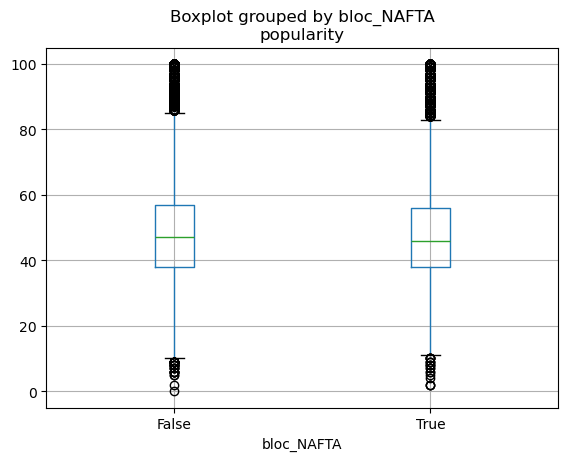

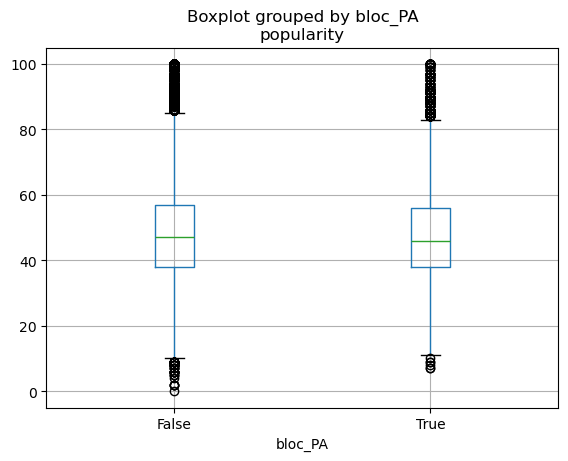

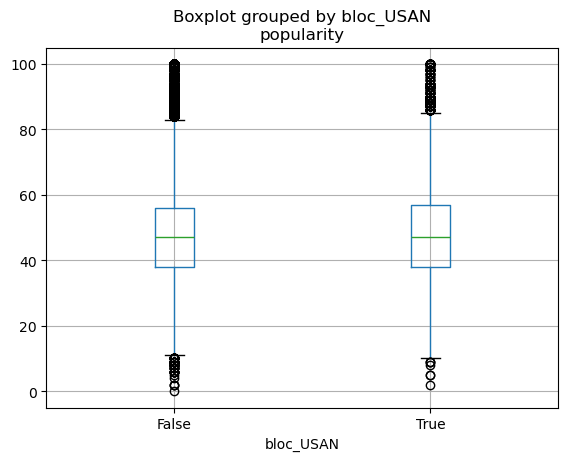

In [325]:
for col in binary_cat_cols:
    combined_df.boxplot(column="popularity", by=col)



Analyzing: track_id


,mean,median,count
track_id,,,
TRK-BEBD53DA84E1,55.0,55.0,1
TRK-7AAF54A5A26C,50.0,50.0,1
TRK-B00FB3BA8500,44.0,44.0,1
TRK-104036BD31E4,42.0,42.0,1
TRK-3F3C8C644B93,41.0,41.0,1
TRK-64C447ECE995,39.0,39.0,1
TRK-D2AFBA0CAFB5,38.0,38.0,1
TRK-D5DA316EC610,37.0,37.0,1
TRK-723A05CA3DC3,34.0,34.0,1



Analyzing: track_name


,mean,median,count
track_name,,,
Stand,53.312500,51.5,32
Ten,52.400000,47.0,30
Work,51.357143,49.5,28
New,49.464286,45.5,28
Shoulder,48.551724,47.0,29
Fine,48.103448,49.0,29
Expert,46.607143,45.0,28
Somebody,46.592593,46.0,27
A,45.000000,41.0,29



Analyzing: artist_name


...

,mean,median,count
latlng,,,
"(54, -2)",48.409419,47.0,8451
"(36, 138)",48.349959,47.0,8581
"(46, 2)",48.341478,47.0,8554
"(-10, -55)",48.316993,47.0,8486
"(51, 9)",48.079326,46.0,8547
"(60, -95)",48.061753,46.0,8615
"(38, -97)",48.059133,47.0,8354
"(-27, 133)",48.048287,47.0,8408
"(-6, 71.5)",48.008929,47.0,8624



Analyzing: demonym


,mean,median,count
demonym,,,
British,48.409419,47.0,8451
Japanese,48.349959,47.0,8581
French,48.341478,47.0,8554
Brazilian,48.316993,47.0,8486
German,48.079326,46.0,8547
Canadian,48.061753,46.0,8615
American,48.059133,47.0,8354
Australian,48.048287,47.0,8408
Indian,48.008929,47.0,8624



Analyzing: currency_code


,mean,median,count
currency_code,,,
GBP,48.409419,47.0,8451
JPY,48.349959,47.0,8581
BRL,48.316993,47.0,8486
EUR,48.210456,46.0,17101
CAD,48.061753,46.0,8615
AUD,48.048287,47.0,8408
USD,48.033632,47.0,16978
MXN,47.954884,46.0,8334


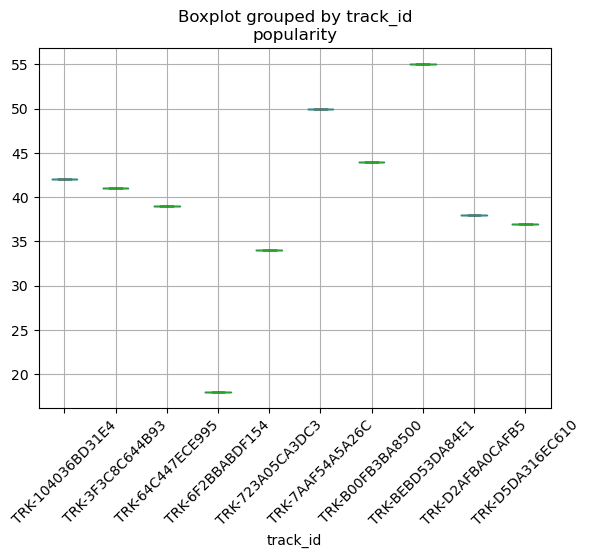

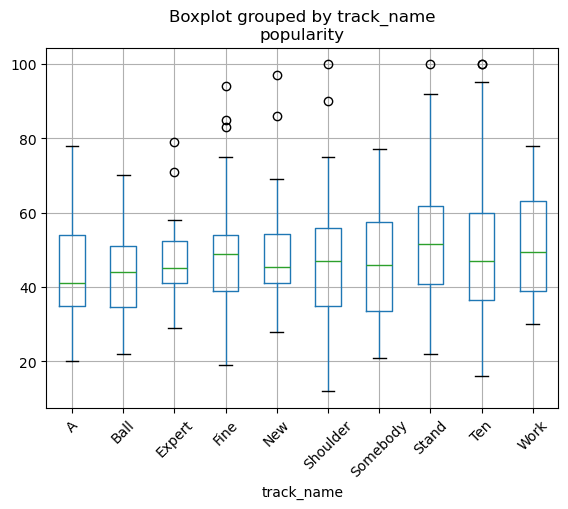

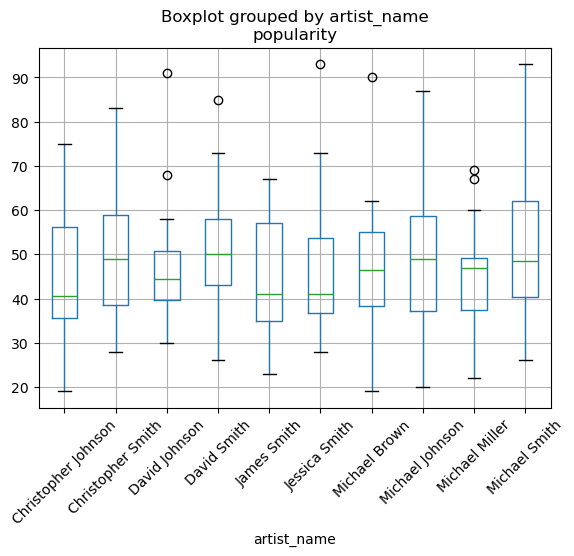

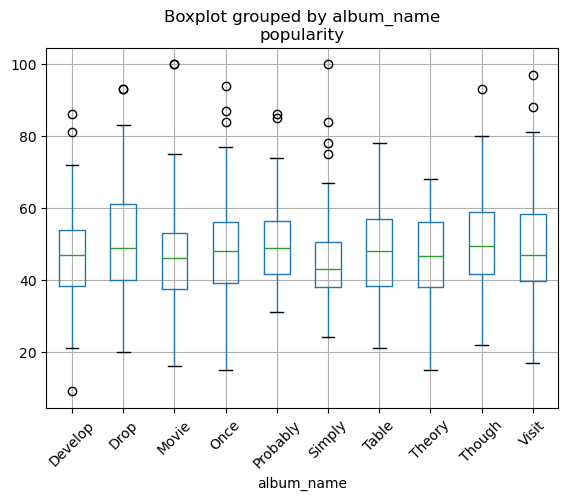

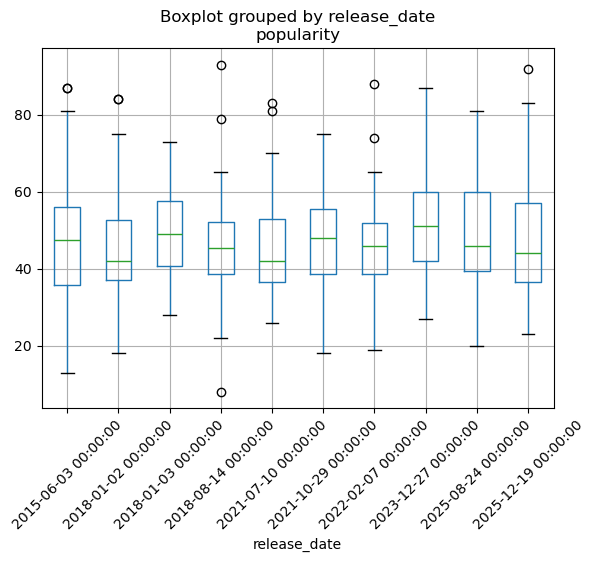

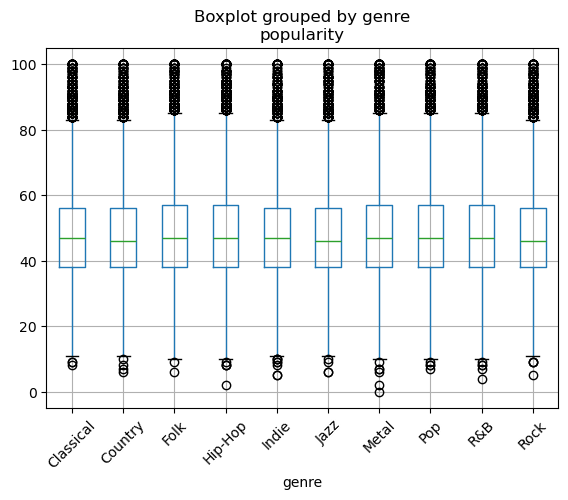

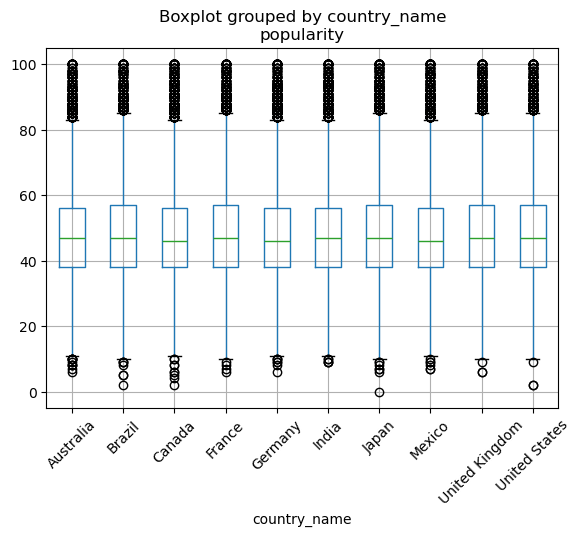

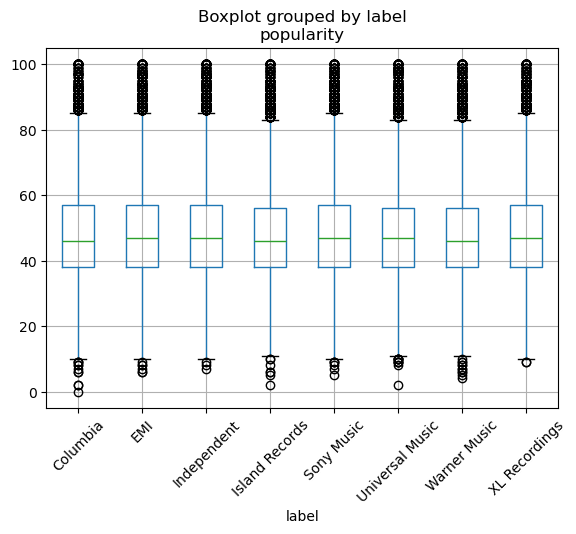

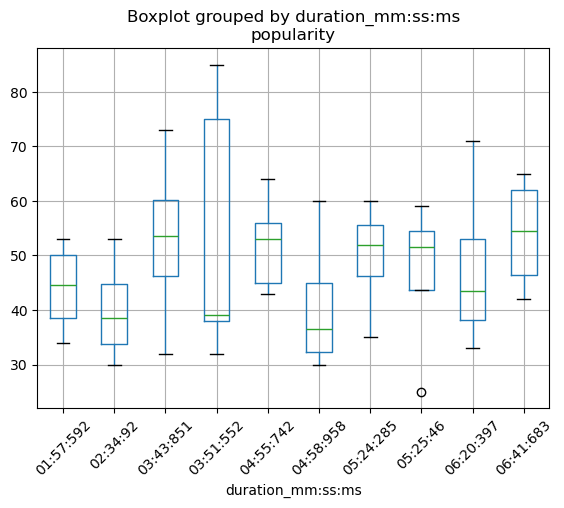

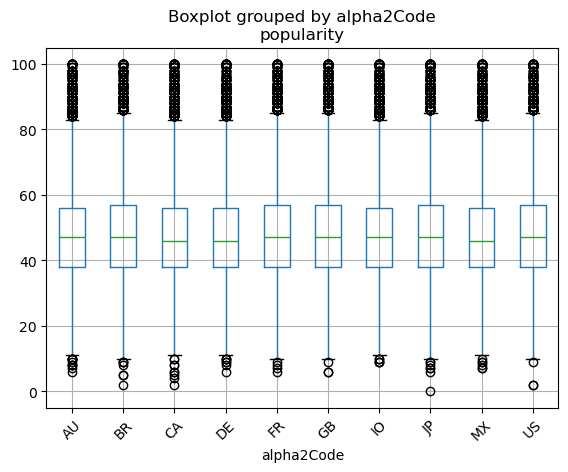

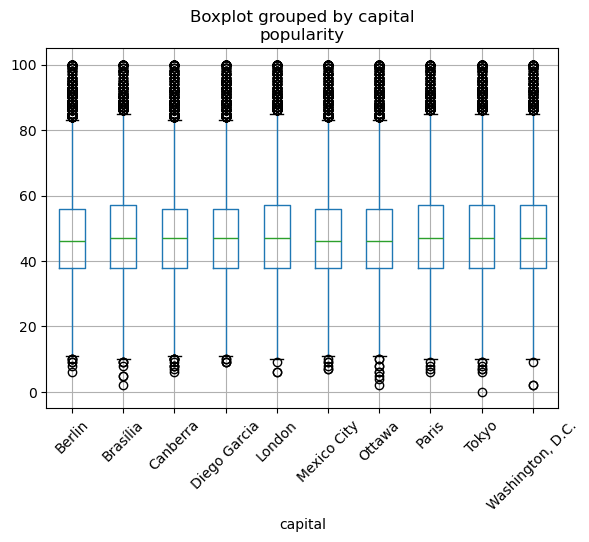

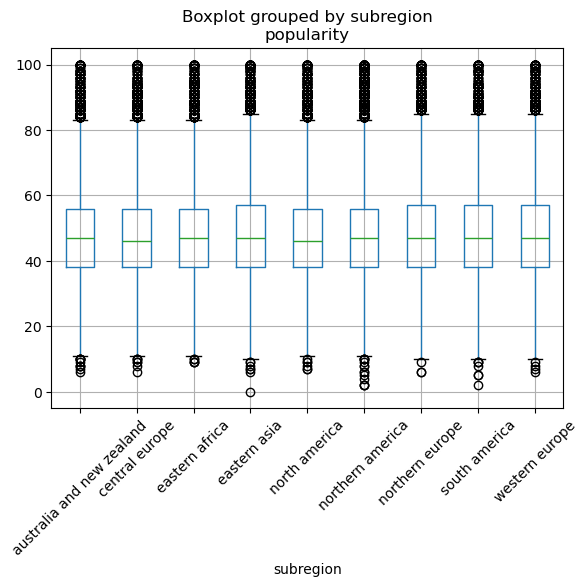

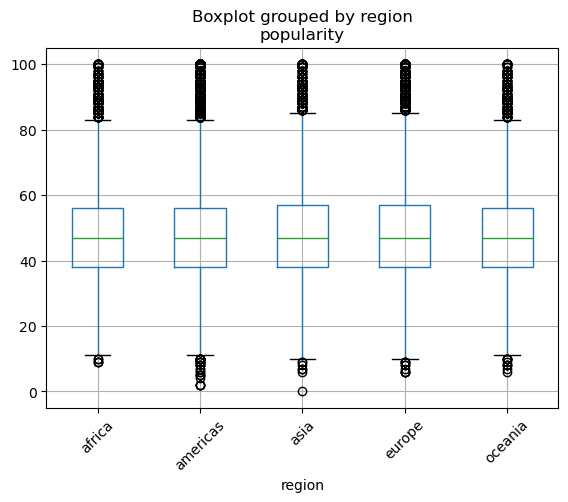

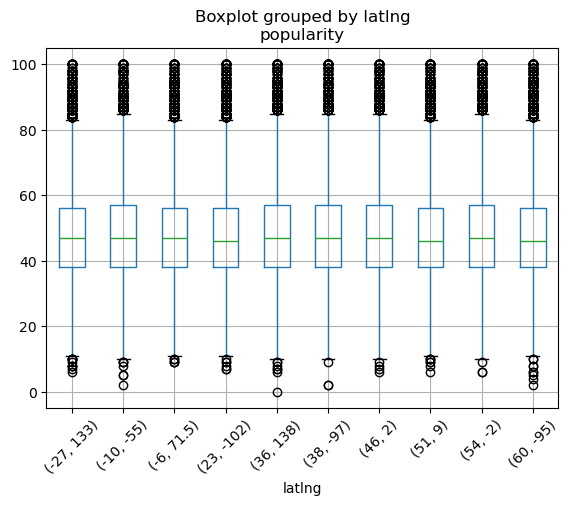

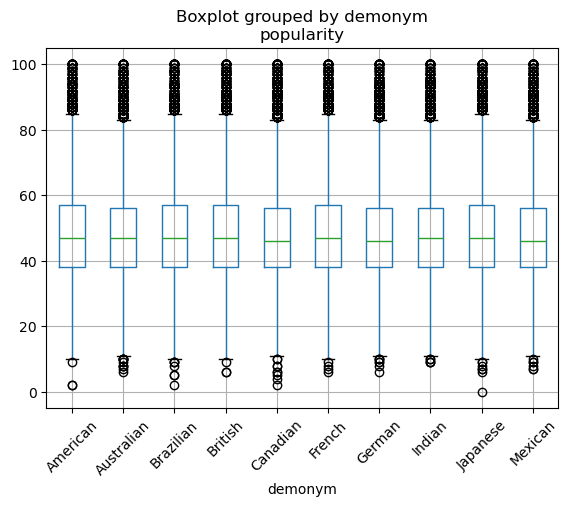

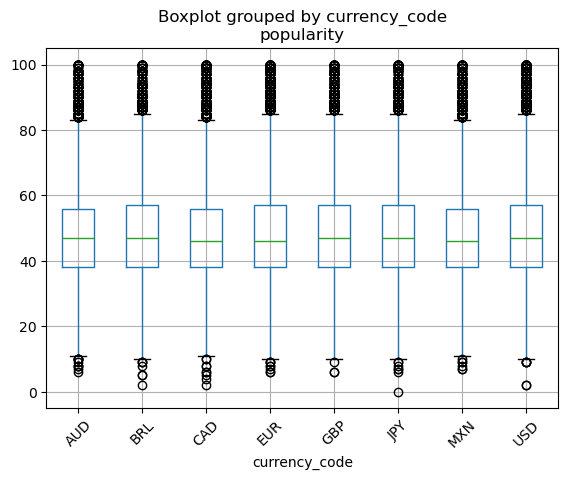

In [326]:
for col in multi_cat_cols:
    print(f"\nAnalyzing: {col}")

    top_categories = (
        combined_df[col]
        .value_counts()
        .head(10)
        .index
    )

    temp_df = combined_df[combined_df[col].isin(top_categories)]

    display(
        temp_df.groupby(col)["popularity"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    temp_df.boxplot(column="popularity", by=col, rot=45)

## EDA Conclusion

During the Exploratory Data Analysis phase, both numerical and categorical features were examined to understand their distributions, relationships, and potential influence on track popularity. Initial distributional analysis revealed a diverse and well-balanced dataset across core audio features, while stream count exhibited strong right skew consistent with real-world listening behavior. Deeper feature-level exploration showed that popularity is not driven by a single dominant factor, but rather reflects a combination of artist-level, genre-level, temporal, and regional influences.

Correlation analysis across numeric and categorical features further supported this finding, indicating that popularity does not exhibit strong linear relationships with individual features. Instead, the results suggest that popularity is shaped by non-linear effects and interactions among multiple variables. Based on these findings, all features were retained for preprocessing and modeling to allow downstream models to capture complex relationships that are not apparent through univariate or linear analysis alone.